# <b>ADM 3080 — Analítica con Python — Universidad San Francisco de Quito</b>
<h2><b>Proyecto de Prueba Técnica</b></h2>
<i>Viernes, 24 de abril de 2026</i>
<hr>
<ul>
    <li><b>Integrantes del Grupo</b>: Santiago Arellano [00328370]</li>
    <li><b>NRC del Curso</b>: 2041</li>
    <li><b>Profesor</b>: Juan Felipe Nájera Puente</li>
</ul>
<hr>

## Sección I: Introducción al Proyecto

En esta sección se presentará una visión general del proyecto, analizando la base de datos y definiendo métricas de calidad para los datos, orientadose en la definición de límites por métricas faltantes e.g. límites porcentuales tolerables de anclajes con inicio pero sin registro de terminación, etc. Además se analizará el tipo de dato esperado por cada una de las clases y se establecerán criterios para la limpieza de datos, incluyendo la identificación y manejo de valores atípicos, datos faltantes y errores de formato. Se discutirá la importancia de la calidad de los datos en el contexto del análisis y cómo una limpieza adecuada puede mejorar la precisión y confiabilidad de los resultados obtenidos a partir de los datos.

### Contexto del Dataset y el Problema

El dataset representa datos registrados de una aplicación de Wellness desarrollada por Yana, una empresa mexicana orientada a ofrecer un servicio de acompañamiento a individuos para desarrollar su mejor versión. Los datos recopilados atienden a una sola sección de la aplicación, el registro de *anclajes* correspondientes a actividades de bienestar como **volver al presente (Present)** o **distraer mi mente (Mind)** registradas junto con la fecha y hora de inicio y terminación de la actividad. Además, el dataset contiene información correspondiente al proceso, sea iniciar o terminar una actividad de anclaje y datos anonimizados de los usuarios.

Debido a las leyes de protección de datos generales, la empresa ha optado por la anonimización de los datos, usando un cifrado, muy probablemente SHA256 o alguna variante interna de tipo *one way* para reducir la posibilidad de identificación de los usuarios. El tipo de cifrado además, dificulta la agregación de datos mediante IDS, por lo que no podemos asumir la posibilidad de identificar el proceso de cerrado y apertura de una actividad en base a un ID específico, dado que los IDs de inicio y terminación de una actividad no necesariamente coincidirán, lo que complica la identificación de actividades completas. Esto se traduce en la necesidad de eliminar esta columna del análisis, tanto el ID registrado bajo la columna de &lt;anonymous&gt; junto con el id registrado en la columna de IDs no son necesarios para un análisis de datos de agregación, no datos por usuario.

En este contexto, la gerencia ha definido diferentes preguntas de análisis que se usarán para orientar diferentes niveles de marketing, UX design y otras áreas afines a esta aplicación y *customer journey* planteado para mejorar la experiencia de usuario.

<hr>

### Preguntas de Análisis expandidas
1. ¿Cuál es la frecuencia de uso de cada técnica de anclaje?
    <blockquote>En este caso, la frecuencia de uso se traduce directamente a la cantidad de sesiones por tecnica de anclaje iniciada, lo que se puede medir de dos formas distintas, agregadas sobre el dataset (visión general para gerencia), o una visión análitica, con un gráfico de área organizado por día de la semana, més o año. En este caso, el dataset proporcionado agrega información diaria, lo que nos permitiría visualizar la tendencia de uso por día de la semana junto con el mes para determinar la relación entre día de la semana y actividad.
    <br><br>
    Asimismo, el nivel de agregación por día se puede usar para medir mediante agregaciones al 100% la distribución porcentual de las actividades registradas, lo que permitiría identificar la técnica de anclaje más utilizada por los usuarios, lo que a su vez podría ser útil para orientar campañas de marketing o mejorar la experiencia de usuario en torno a esta técnica.
    <br><br>
    En este contexto, entonces, hay tres diferentes formas de evaluar esta frecuencia, la primera es una agregación totalizada, que permite ver durante todo el periodo de análisis los resultados de las actividades, la segunda es una visualización por día mediante líneas, mostrando la suma totalizada de actividades, y la tercera es una distribución porcentual por día, más visual, más facil de entender para personas no técnicas y con poco tiempo para revisar visualizaciones complejas.
    </blockquote>
2. ¿Qué porcentaje de usuarios finaliza cada tipo de ejercicio?
    <blockquote>
    Para esta pregunta, la información importante es la visión desglosada por día y por tipo de actividad. Cuando hablamos de porcentaje de usuarios finalizados, debemos de tomar en cuenta que para cada tipo de actividad existe la posibilidad que un usuario entre, y nunca salga, o entre y salga, o entre y salga de la aplicación y no termine la actividad, por lo que tenemos que comparar la cantidad de registros de inicio y fin de actividades. De nuevo esta pregunta tiene dos niveles diferentes de agregación. El nivel general, del dataset completo, corresponde a la totalización de eventos cerrados y abiertos y la diferencia porcentual para evaluar si existen deficiencias entre la apertura de algunos tipos de actividades comparados con otros, lo que podría indicar problemas de experiencia de usuario o falta de interés en ciertas actividades.
     <br><br>
     El segundo nivel de análisis corresponde a la evaluación por día, lo que permitiría identificar tendencias específicas en ciertos días de la semana o meses, lo que podría ser útil para orientar campañas de marketing o mejorar la experiencia de usuario en torno a estas técnicas. Para la primera visualización, una visualización en torno a barras apiladas al 100% sería ideal para mostrar la distribución porcentual a nivel de actividades, mientras que para la visión diaria, una visualización de líneas mostrando la tendencia de finalización por día sería ideal para mostrar la evolución de esta métrica a lo largo del tiempo.
     <br><br>
     Una tercera visualización efectiva corresponde a usar un diagrama de tipo sankey donde todos los usuarios registrados que han iniciado se distribuyan a la terminación de sus eventos, este tipo de gráfico es fuerte para una visualización de transición en el flujo y es intuitivo dado que mostraría la diferencia entre el ingreso de usuarios al iniciar la actividad y la baja cantidad de usuarios posibles al terminar la misma.
    </blockquote>
3. ¿Qué técnicas suelen utilizarse juntas en una misma sesión o en momentos cercanos?
    <blockquote>
    Para esta pregunta, es importate definir primero que significa durante una misma sesión, o durante momentos cercanos. Dado que no tenemos una información accionable del usuario, dado que no tenemos IDs agrupables y no tenemos forma de regresar de la encriptación de los PII de los usuarios, no podemos analizar en general mediante usuarios. Por otro lado, si bien tenemos inforamción de fecha y hora, no existe un registro que indique que estos eventos fueron parte de una misma sesión, por lo que para esta pregunta vamos a asumir que **una sesión dentro de la aplicación puede dura una hora o más** que sería nuestro indicador de que si dentro de una misma sesión (en el rango de 1 hora) se inician más de una actividad entonces tenemos una sesión y podemos evaluar la cantidad de eventos que se realizan juntos.
    <br><br>
    Para evaluar eventos que se realizen en eventos cercanos, podemos usar una noción de que un evento cercano corresponde a eventos **que se inician dentro de 30 minutos** entre sí, lo que nos permitiría centrar este concepto de momentos cercanos y analizar que eventos se inician seguidos en un periodo de 30 minutos de análisis luego de una actividad iniciada.
    </blockquote>

<hr>

### Guía base de la estructura del dataset

Los datos están distribuidos en un solo archivo *CSV*, importando desde *GitHub Raw links* para mayor comodidad a la hora de ejecutar este cuaderno de Python en otros sistemas en donde el acceso a archivos csv, la forma de manejar archivos del sistema operativo o la ubicación del archivo podrían causar problemas de ejecución innecesarios. En base de este archivo *CSV* y la guía del dataset se ha definido el siguiente listado de los campos y su respectiva descripción.

 <div style="display: flex; align-items:center; align-self:center; justify-content:center">
  <table style="margin: auto; border-collapse: collapse; width: 80%; text-align: center; border: 1px solid black;">
      <thead>
          <tr style="background-color: #f2f2f2;">
              <th style="border: 1px solid black; padding: 8px;">Campo</th>
              <th style="border: 1px solid black; padding: 8px;">Tipo de Dato Esperado</th>
              <th style="border: 1px solid black; padding: 8px;">Descripción</th>
          </tr>
      </thead>
      <tbody>
          <tr>
              <td style="border: 1px solid black; padding: 8px;">id</td>
              <td style="border: 1px solid black; padding: 8px;">Entero</td>
              <td style="border: 1px solid black; padding: 8px;">ID de identificación única del registro</td>
          </tr>
          <tr>
              <td style="border: 1px solid black; padding: 8px;">event</td>
              <td style="border: 1px solid black; padding: 8px;">Texto</td>
              <td style="border: 1px solid black; padding: 8px;">Tipo de evento registrado</td>
          </tr>
          <tr>
              <td style="border: 1px solid black; padding: 8px;">techniqueID</td>
              <td style="border: 1px solid black; padding: 8px;">Texto</td>
              <td style="border: 1px solid black; padding: 8px;">ID de la técnica utilizada</td>
          </tr>
          <tr>
              <td style="border: 1px solid black; padding: 8px;">date</td>
              <td style="border: 1px solid black; padding: 8px;">Fecha</td>
              <td style="border: 1px solid black; padding: 8px;">Fecha en que ocurrió el evento</td>
          </tr>
      </tbody>
  </table>
  </div>

En el contexto del trabajo de análisis a desarrollar, notamos que la parte más importante a considerar es el desarrollo de métricas de calidad para las columnas de evento, tipo de técnica y fecha, dado que en base a estas se construye todo el análisis base de las preguntas definidas para la prueba.

<hr>

### Consideraciones de Limpieza por Columna

No se considera necesario la modificación de la columna de ID (será eliminada al no ser útil para la identificación de patrones de usuarios o de actividades), y tampoco para techniqueID dado que los datos registrados se encuentran definidos en base a las mismas clases, lo que garantiza que no existan datos incorrectos en esta clase.

#### <code>event</code>

<i><small>Esta columna, que define el tipo de evento disparado desde la UI de la aplicación para el módulo de actividades de anclaje puede tomar dos valores específicos: <code>{"Grounding Started","Grounding Ended"}</code> que corresponden al inicio y fin de una actividad de anclaje que registra los datos de esta en las columnas adicionales de date y techniqueID.</small></i>

El principal problema de event es que no sabemos si los eventos se disparan solo por **terminar una sesión** o si también se disparan **automáticamente cuando una sesión no se termina por mucho tiempo**, o si por ejemplo se disparan cuando el **usuario sale de la aplicación durante una sesión**. Esta ambigüedad de la razón de terminación es un problema considerable dado que:
1. Si la sesión marcó **Grounding Ended** debido a un timeout en una actividad, no se la puede considerar como cerrada y por ejemplo esto sería una clase faltante en los datos, que sería una clase de tipo *Grounding Timeout* que de estar presente nos permitiría identificar una tercera clase de terminación útil para un análisis adicional, lo que puede ser una sugerencia de mejora para el equipo de sistemas con respecto a los datos recopilados por la aplicación.
2. Si la sesión marcó **Grounding Ended** debido a una salida de la aplicación por el usuario entonces es posible que tengamos multiples registros de *Grounding Ended* seguidos si por ejemplo el usuario tiene que responder a llamadas, mensajes, o atender a otros requerimientos de sus vidas por fuera de la aplicación. Esta puede ser una razón por la que existen varios registros seguidos, que varían por minutos en algunos casos, de terminaciones.
3. Si la sesión marcó **Grounding Ended** debido a una terminación normal, entonces no existe un problema de calidad de datos, dado que el evento se disparó correctamente y se puede usar para el análisis.

Dado que una visión general de los datos basados en el archivo .csv propuesto, muestra que los primeros datos registran un evento de **Grounding Start** y luego cinco diferentes eventos de cierre a la misma hora, con una duración de 1 minuto luego de una apertura de proceso, esto nos muestra que puede existir un problema de calidad de datos con respecto al segundo escenario de **Grouding Ended**.

<b><small>En este caso, aunque no podemos inferir que tipo de datos se registran en los registros duplicados, podemos tomar dos rutas diferentes de análisis, eliminando entradas duplicadas en base del tipo de evento, acción y hora, lo que nos podría ayudar a reducir el problema de duplicados, otra alternativa es notar su existencia pero mantenerlos en el dataset para argumentar sobre ellos luego</small></b>

#### <code>date</code>

<hr style="height:1px;border:none;color:#333;background-color:#333;">

<i><small>Esta columna registra la fecha y hora exacta de inicio y fin de la actividad. La fecha se registra en un formato de mm/dd/yyyy formato que es similar al usado en EEUU, lo que nos permite una conversión directa en terminos de fecha para su análisis posterior. Además el dataset registra la fecha en formato hh:mm con formato de 24h en lugar de solo 12, lo que nos indica un formato de datos mucho más estandarizado enfocado en la utilidad de los datos bajo sistemas estandarizados para formatos en-US y hora basado en 24.</small></i>

En este caso, en base a la columna de fecha y hora podemos realizar los siguientes pasos de análisis:

1. Primero, **dividir la columna de date en dos, date y time** para poder realizar análisis de datos diferenciados sin tener que realizar una modificación *inline* a la columna de datos durante el análisis.
2. Segundo, **derivar día de la semana, nombre del día, mes, año y nombre del mes** en base de la columna de *date* para extraer datos para agregaciones de tipo timeseries en base a fechas en primera instancia y para agrupaciones por día de la semana o nombre del mes.
3. Tercero, **en base a nuestros periodos base de longitud de actividad y eventos cercanos** podemos derivar columnas de tipo *session* y *eventos cercanos* para poder realizar análisis de tipo sesión y eventos cercanos, lo que nos permitiría responder a la pregunta número 3 de nuestro análisis.

<b><small>En este caso, no existe una remediación de datos necesaria pero si una derivación de columnas adicionales para un análisis profundo de datos.</small></b>

### Librerías Requeridas para el Análisis

Para el presente proyecto, se ha optado por trabajar mediante un entorno *managed* de Python a través de *Python Venv(s)* permitiendo el aislamiento de las librerías requeridas para el trabajo. En este contexto, los comandos a ejecutar a continuación se encargan de la instalación de varias librerías para el trabajo, lo que requiere que Python se encuentre instalado y definido dentro del **PATH** o en su caso, en la carpeta de configuración */bin* o */sbin*.
<br><br>
Para la realización del trabajo, se ha considerado necesario la inclusión de diversas librerías. El siguiente listado detalla la razón de la inclusión de la librería en el desarrollo del proyecto:

<div style="display: flex; align-items:center; align-self:center; justify-content:center">
<table style="margin: auto; border-collapse: collapse; width: 80%; text-align: justify; border: 1px solid black;">
    <thead>
        <tr style="background-color: #f2f2f2;">
            <th style="border: 1px solid black; padding: 8px;">Librería</th>
            <th style="border: 1px solid black; padding: 8px;">Uso</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Numpy</td>
            <td style="border: 1px solid black; padding: 8px;">Librería de análisis numérico con fuertes características para operaciones algebráicas, matriciales y con un backend implementado en C++ por lo que permitirá la realización de operaciones numéricas rápidamente.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Pandas</td>
            <td style="border: 1px solid black; padding: 8px;">Librería base para el análisis del archivo CSV, su manipulación en forma de carga, datos, y agregaciones que permitirán dar respuesta a las preguntas de investigación definidas.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Matplotlib</td>
            <td style="border: 1px solid black; padding: 8px;">Base de las visualizaciones en el caso de ser necesarias para el desarrollo del proyecto o la exploración visual de los datos.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Seaborn</td>
            <td style="border: 1px solid black; padding: 8px;">Apoyo a Matplotlib en el caso de requerir visualizaciones más avanzadas.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Squarify</td>
            <td style="border: 1px solid black; padding: 8px;">Apoyo a Matplotlib para la realización de Treemaps en Python.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">SciPy</td>
            <td style="border: 1px solid black; padding: 8px;">Para pruebas de hipótesis estadísticas (t-test, Mann-Whitney, etc.).</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">WordCloud</td>
            <td style="border: 1px solid black; padding: 8px;">Para mapas de palabras como visualizacion de peso por clase.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Plotly</td>
            <td style="border: 1px solid black; padding: 8px;">Para gráficos adicionales.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">MissingNo</td>
            <td style="border: 1px solid black; padding: 8px;">Para gráficos adicionales especializados en al visualización de valores nulos.</td>
        </tr>
    </tbody>
</table>
</div>
<br><br>
En este contexto, las librerías seran importadas  usando un álias al nombre original para facilidad de uso durante el desarrollo del proyecto.

In [196]:
#? 1. Importacion de librerias para el proyecto
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify as sqs
import plotly as plty
import wordcloud as wdc
import missingno as mno


### Importe del Dataset

In [197]:
#? 1. Importamos el dataset directamente desde su archivo para evitar problemas con la red

dataset_location = '../../../src/res/data/ProyectoPruebaTecnicaADM3080_YanaRaw.csv'

data_as_is = pd.read_csv(dataset_location, sep=',')
data_to_explore = data_as_is.copy(deep=True)
data_cleaned = data_as_is.copy(deep=True)

## Sección II: Análisis de Calidad de los Datos Iniciales

En esta sección se realizará un análisis inicial de los datos, revisando distribución de valores mediante agrupaciones, conteos, visualizaciones de peso mediante wordcloud, y conteo de nulos. Para valores de tipo fecha se realizará un análisis en base a una corrección inline (previa a la definición del dataset procesado) para analizar la distribución de fechas y de horas visualmente.


### Exploracion Inicial de los Datos

In [198]:
#? 1. Exploracion de la forma del dataset, describe e info
print(f"El dataset tiene {data_as_is.shape[0]} filas")
print(f"El dataset tiene {data_as_is.shape[1]} columnas")


El dataset tiene 540023 filas
El dataset tiene 5 columnas


In [199]:
#? 2. Exploracion de las variables del dataset
data_as_is.describe(include='all')

,Unnamed: 0,id,event,techniqueID,date
count,5.400230e+05,5.400230e+05,540023,540023,540023
unique,NaN,NaN,2,5,80416
top,NaN,NaN,Grounding Ended,present,2/9/2022 15:10
freq,NaN,NaN,272487,168500,131
mean,6.629799e+05,6.656979e+05,NaN,NaN,NaN
std,3.817372e+05,3.817372e+05,NaN,NaN,NaN
min,1.000000e+00,2.719000e+03,NaN,NaN,NaN
25%,3.330420e+05,3.357600e+05,NaN,NaN,NaN
50%,6.628060e+05,6.655240e+05,NaN,NaN,NaN
75%,9.935295e+05,9.962475e+05,NaN,NaN,NaN


In [200]:
#? 3. Exploracion del dataset mediante info
data_as_is.info()

<class 'pandas.DataFrame'>
RangeIndex: 540023 entries, 0 to 540022
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Unnamed: 0   540023 non-null  int64
 1   id           540023 non-null  int64
 2   event        540023 non-null  str  
 3   techniqueID  540023 non-null  str  
 4   date         540023 non-null  str  
dtypes: int64(2), str(3)
memory usage: 39.9 MB


En este contexto, notamos que el dataset no contiene valores nulos, lo que nos muestra que en realidad el dataset estaría limpio, aunque sabemos que existen errores lógicos de registro de datos, hasta donde se puede observar en las columnas presentes no existen errores de registro.

Además, el tipo de dato de las columnas nos muestra que el error registrado corresponde a `date` en donde el tipo de dato se registra como una cadena de texto en lugar de un tipo datetime, por lo que la corrección en este case se centrará en esta columna.

Por otro lado, notamos que el tipo de evento corresponde a una columna de tipo string, que podríamos convertir en columnas numéricas booleanas en base a un proceso de One Hot Encoding en esa columna.

Por último, notamos que tenemos una columna `Unnamed: 0` e `id` que podemos eliminar dado que no representan información útil para el análisis.

In [201]:
#? 4. Exploracion de los datos mediante una visualizacion de los diez datos iniciales y finales del dataset

print(f"{'Valores Iniciales':=^120}")
display(data_as_is.head(10))
print()
print(f"{'Valores Finales':=^120}")
display(data_as_is.tail(10))

===================================================Valores Iniciales====================================================


,Unnamed: 0,id,event,techniqueID,date
0,1,2719,Grounding Started,present,1/12/2022 14:06
1,2,2720,Grounding Ended,present,1/12/2022 14:06
2,3,2721,Grounding Ended,present,1/12/2022 14:07
3,4,2722,Grounding Ended,present,1/12/2022 14:07
4,5,2723,Grounding Ended,present,1/12/2022 14:07
5,6,2724,Grounding Ended,present,1/12/2022 14:07
6,10,2728,Grounding Started,categories,1/12/2022 14:07
7,11,2729,Grounding Ended,categories,1/12/2022 14:08
8,15,2733,Grounding Started,body,1/12/2022 14:08
9,17,2735,Grounding Ended,body,1/12/2022 14:09



====================================================Valores Finales=====================================================


,Unnamed: 0,id,event,techniqueID,date
540013,1323276,1325994,Grounding Ended,present,3/16/2022 16:44
540014,1323278,1325996,Grounding Ended,categories,3/16/2022 16:44
540015,1323282,1326000,Grounding Started,categories,3/16/2022 16:44
540016,1323283,1326001,Grounding Started,categories,3/16/2022 16:44
540017,1323284,1326002,Grounding Ended,present,3/16/2022 16:44
540018,1323286,1326004,Grounding Ended,present,3/16/2022 16:45
540019,1323287,1326005,Grounding Ended,present,3/16/2022 16:45
540020,1323292,1326010,Grounding Ended,categories,3/16/2022 16:45
540021,1323299,1326017,Grounding Started,body,3/16/2022 16:46
540022,1323300,1326018,Grounding Started,present,3/16/2022 16:46


### Drill Down por Atributo: exploración de las características internas del dataset por columna de datos

<hr>

#### Exploración de event

Para esta variable, se realizará un análisis de la cantidad de registros de cada tipo de variable, para realizar una visualización general y luego agregada por cada tipo de evento. Dado que no tenemos una variable numérica, no se realizará ningún análisis de tipo de distribución.

In [202]:
#? 1. Exploracion del conteo de valores nulos, negativos si existen y no nulos positivos
print(f"{'Conteo General de valores: Nulos, No Nulos y Negativos, No Nulos y Positivos':=^120}")
result = pd.DataFrame(data={
    'Conteo de Nulos': data_as_is['event'].isna().sum(),
    'Conteo No Nulo ': data_as_is['event'].count()
},index=['Conteo']).T

result.loc['Total',:] = result.sum(axis=0)

result

======================Conteo General de valores: Nulos, No Nulos y Negativos, No Nulos y Positivos======================


,Conteo
Conteo de Nulos,0.0
Conteo No Nulo,540023.0
Total,540023.0


In [203]:
#? 2. Exploracion de la distribucion entre evento terminado y evento iniciado
print(f"{'Conteo de eventos por tipo':=^120}")
result = data_as_is['event'].value_counts().T.to_frame()


for entry in result.index:
    count = result.loc[entry, "count"]
    percentage = (count / data_as_is.shape[0]) * 100
    result.loc[entry, "Percentage"] = percentage
result


===============================================Conteo de eventos por tipo===============================================


,count,Percentage
event,,
Grounding Ended,272487,50.458406
Grounding Started,267536,49.541594


In [204]:
#? 2.1 Exploracion de la diferencia de valores generales del dataset en el tipo de eventos
print(f"Diferencia Iniciados  - Terminados: {result.loc['Grounding Started','count'] - result.loc['Grounding Ended','count']}")

Diferencia Iniciados  - Terminados: -4951


Como podemos notar, en la visión de los datos generales, tenemos 4951 entradas más de tipo **Grounding Ended** que las entradas que tenemos de tipo **Grounding Stared** lo que nos indica que en general el dataset está desbalanceado en un 1% de los datos hacia el conteo de eventos de terminación comparado con los eventos de inicio de anclajes.

Si bien la visión general es alentadora para la distribución paritaria de las clases, el siguiente análisis, orientado a los diferentes tipos de anclajes y el conteo de los valores de ended o started puede resultar aún más revelador.

In [205]:
#? 3. Exploracion de la distribucion de eventos de inicio y finalizacion por cada tipo de anclaje
result = data_as_is.groupby(by='techniqueID')['event'].value_counts(sort=True)


conteo_y_proporcion_de_eventos_por_tecnica = pd.DataFrame(
    {
        "conteo": result,
        "proporcion": result.groupby(level=0).transform(lambda x: x /x.sum()).apply(lambda v: f"{round(v*100,2)} %")
    },
    index = result.index
)

conteo_y_proporcion_de_eventos_por_tecnica

conteo proporcion
techniqueID event                               
body        Grounding Started   48989    59.54 %
            Grounding Ended     33293    40.46 %
breathing   Grounding Started   39173    55.81 %
            Grounding Ended     31019    44.19 %
categories  Grounding Started   86433    67.56 %
            Grounding Ended     41497    32.44 %
mind        Grounding Started   55539    60.95 %
            Grounding Ended     35580    39.05 %
present     Grounding Ended    131098     77.8 %
            Grounding Started   37402     22.2 %

En este caso, notamos que para las clases de **body y breathing** el dataset muestra información espearada, es decir, que los eventos de *°Grounding Started* tengan un mayor porcentaje comparado con *Grounding Ended* lo que indica que los clientes tienden a terminar este tipo de actividades.

Por otro lado, notamos casos como el de **categories o mind** en donde el conteo de actividades de inicio es casi el doble del conteo de datos para los eventos de terminación de las actividades, lo que nos muestra que estos tipos de anclaje *generalmente se inician (lo que es bueno para la empresa), pero no se terminan*.

Por último, el caso más extraordinario corresponde al caso de **present** en donde la proporción se invierte, hay muchos más registros de terminación (es decir de tipo *Grounding Ended*) comparado con los registros de tipo *Grounding Started* lo que nos muestra un problema claro en el registro de datos. Si tomamos en cuenta nuestro análisis del tipo posible de registros de *Grounding Started*, si consideramos que esta columna registra un evento de tipo de finalización y que la razón entre un registro de inicio con el de finalización es de casi 4 a 1, tenemos un problema de que **aparentemente la mayoría de las personas terminan actividades present, sin siquiera haber pasado por un flujo que inicie la actividad o registre su inicio**

Esto puede apuntar a dos problemas técnicos de la aplicación y recopilación de datos.
1. Dada la alta tasa de valores de terminación comparada con los valores iniciales, la aplicación tiene un problema real en el registro de la actividad de tipo **present**, en específico, el registro de inicio de actividad no está registrando el punto de inicio de la actividad, y esto genera que muchos usuarios que pueden estar usando la aplicación, vean su actividad como terminada pero el sistema nunca la vió como siquiera iniciada.
2. Por otro lado, si el sistema no tiene un problema al registrar actividades, entonces el problema corresponde al proceso de *signaling* de terminación de la actividad. Es posible que el sistema registre apropiadamente 37K eventos de inicio, los eventos reales de los usuarios, pero al final registre este dato tres o cuatro veces por problemas en el diseño del backend de la aplicación, donde se crean multiples registros en la base de datos de un mismo usuario. En este caso, el problema de calidad de datos es claro, y se recomienda una revisión del proceso de registro de datos para esta actividad, dado que el análisis de los datos muestra un problema claro en la calidad de los datos registrados para esta actividad, lo que puede afectar la precisión y confiabilidad de los resultados obtenidos a partir de estos datos.

De cualquier forma, notamos que existen dos problemas paralelos en el dataset, y que afectan de manera distinta a cada uno de los tipos de anclaje.

1. El primer problema corresponde a un problema de calidad de datos para la actividad de tipo **present** en donde el sistema no registra apropiadamente los eventos de inicio, lo que genera un desbalance claro entre los eventos de inicio y terminación, lo que puede afectar la precisión y confiabilidad de los resultados obtenidos a partir de estos datos.
2. El segundo problema corresponde a un problema de calidad de datos para las actividades de tipo **body, breathing, categories y mind** en donde el sistema registra muchas más actividades de inicio que actividades de finalización, lo que puede indicar un problema de registro de la aplicación, como se mencionó en casos de que no tolere salidas de la aplicación, no tenga timeouts establecidos, o no tolere cancelaciones con otro tipo. En este caso, dado que el porcentaje de los datos se acumula en los eventos de inicio de actividad, el problema claramente recae en un sistema de ingesta de datos que no prevee situaciones como salidas de la aplicación en donde un usuario puede no regresar a la aplicación *por horas o días* y si el sistema solo deja de mantener un estado vivo de esa actividad, entonces claramente tendríamos actividades huérfanas.

Desde nuestro punto como analístas no podemos realizar una modificación de los datos, ni una imputación porque no podemos asumir que hubo un timeout o una salida de la aplicación en base de los datos registrados. Además, el ID incremental del usuario no nos permite realizar uniones para determinar si son eventos reales o duplicados, dado que hasta donde ve el sistema, los eventos son unicos y coherentes.

Una posible solución es la eliminación de los datos duplicados teniendo en cuenta un subset de columnas, es decir, evento, el ID de la actividad y la hora, para reducir la cantidad de eventos duplicados a una copia única de cada registro e igualar los datos. Si bien este mecanismo es útil, dado que afecta  la columna de eventos es posible que elimine registros reales de inicio de actividades por ser al mismo momento o la misma actividad (lo que podría apuntar a que la aplicación registra eventos registrados rápidamente como un doble clic sobre el botón de iniciar actividad dos veces), y lo que podría eliminar registros de tipo cancelación duplicados, o eventos reales que cancelan actividades de varios usuarios.

En general como el dataset contiene datos de diferentes usuarios, no se considera apropiado la eliminación o imputación de datos, dado que representan falencias del sistema y no datos poco problables o poco útiles para nuestro análisis.

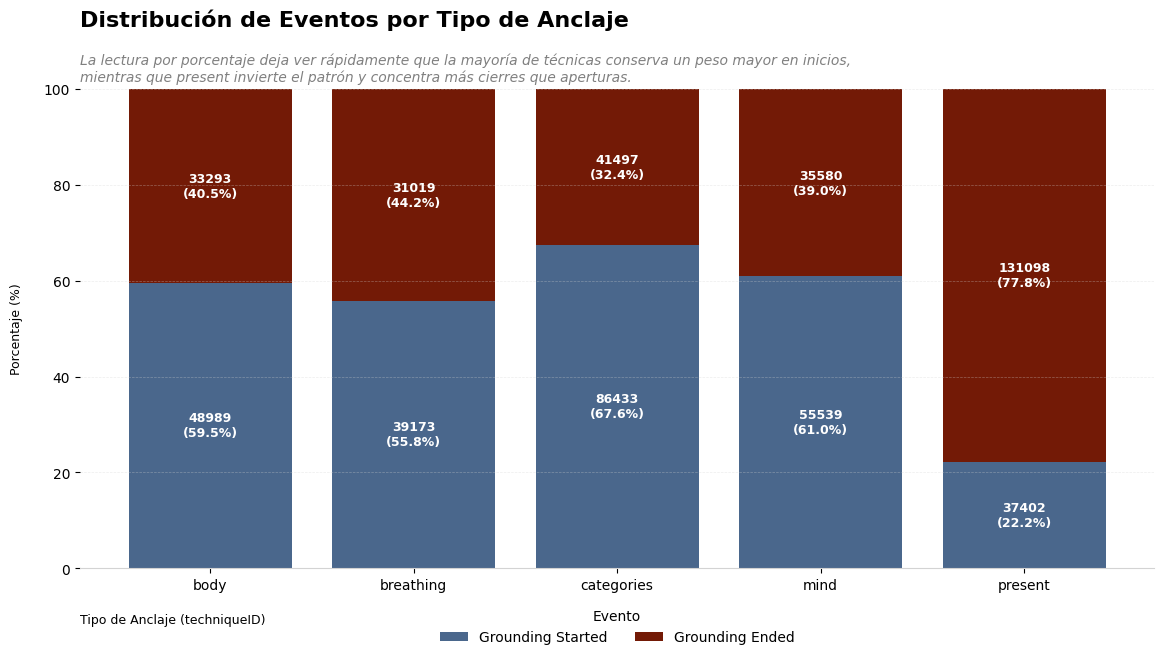

In [206]:
from seaborn.palettes import _ColorPalette


#? 4. Exploracion visual de los conteos de porcentajes por cada tipo de anclaje

def generate_blue_palette(n: int) -> _ColorPalette:
    """
    Funcion encargada de generar una paleta de colores replicable en base de la paleta built-in de Blues de Seaborn
    y usando el parametro n para determinar cuantos colores generar y retornar para la visualizacion
    :param n: entero representativo de la cantidad de colores necesarios
    :return: listado de colores
    """
    return sns.color_palette("Blues", n)

#? 3.1 Preparacion de datos para el stacked bar chart
stacked_data = data_as_is.groupby('techniqueID')['event'].value_counts().unstack(fill_value=0)
stacked_data = stacked_data.reindex(columns=['Grounding Started', 'Grounding Ended'])
stacked_pct = stacked_data.div(stacked_data.sum(axis=1), axis=0) * 100

#? 3.2 Visualizacion de distribucion de eventos por tipo de anclaje
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#4A678C', '#731A06']

bottom = np.zeros(len(stacked_pct))
for i, col in enumerate(stacked_pct.columns):
    bars = ax.bar(stacked_pct.index, stacked_pct[col], bottom=bottom, color=colors[i], label=col)
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:
            count = stacked_data.iloc[j][col]
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + height / 2,
                f'{count}\n({height:.1f}%)',
                ha='center',
                va='center',
                fontsize=9,
                color='white',
                fontweight='bold'
            )
    bottom += stacked_pct[col].values

#? Titulo y subtitulo storytelling
ax.set_title(
    'Distribución de Eventos por Tipo de Anclaje',
    fontsize=16,
    fontweight='bold',
    loc='left',
    pad=45
)
subtitle = (
    'La lectura por porcentaje deja ver rápidamente que la mayoría de técnicas conserva un peso mayor en inicios,\n'
    'mientras que present invierte el patrón y concentra más cierres que aperturas.'
)
ax.text(
    0.0,
    1.01,
    subtitle,
    transform=ax.transAxes,
    fontsize=10,
    fontstyle='italic',
    color='gray',
    va='bottom',
    ha='left'
)

ax.set_xlabel('Tipo de Anclaje (techniqueID)', fontdict={'fontsize': 9}, labelpad=15, ha='left', x=0)
ax.set_ylabel('Porcentaje (%)', fontdict={'fontsize': 9}, labelpad=15)
ax.set_ylim(0, 100)

#? Estilo minimalista
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('lightgray')
ax.grid(True, axis='y', color='lightgray', linestyle='--', alpha=0.4)
ax.legend(title='Evento', loc='upper center', frameon=False, bbox_to_anchor=(0.5, -0.06), ncol=2)

plt.tight_layout(pad=2.0)
plt.show()


#### Exploración de techniqueID

Para esta columna se trabajará con un análisis similar, pero dado que el análisis relacionado con el conteo de datos de event ya se realizó, nos centraremos en la distribución de valores en la clase general solamente, para evaluar si de antemano existe alguna agrupación de tipos de anclajes.

In [207]:
#? 1. Exploracion del conteo de valores nulos, negativos si existen y no nulos positivos
print(f"{'Conteo General de valores: Nulos, No Nulos y Negativos, No Nulos y Positivos':=^120}")
result = pd.DataFrame(data={
    'Conteo de Nulos': data_as_is['techniqueID'].isna().sum(),
    'Conteo No Nulo ': data_as_is['techniqueID'].count()
},index=['Conteo']).T

result.loc['Total', :] = result.sum(axis=0)

result

======================Conteo General de valores: Nulos, No Nulos y Negativos, No Nulos y Positivos======================


,Conteo
Conteo de Nulos,0.0
Conteo No Nulo,540023.0
Total,540023.0


In [208]:
#? 2. Exploracion de la distribucion de tipos de anclajes
print(f"{'Conteo de eventos por tipo':=^120}")
result = data_as_is['techniqueID'].value_counts().T.to_frame()

result.loc['Total',:] = result.sum(axis=0)

result

===============================================Conteo de eventos por tipo===============================================


,count
techniqueID,
present,168500.0
categories,127930.0
mind,91119.0
body,82282.0
breathing,70192.0
Total,540023.0


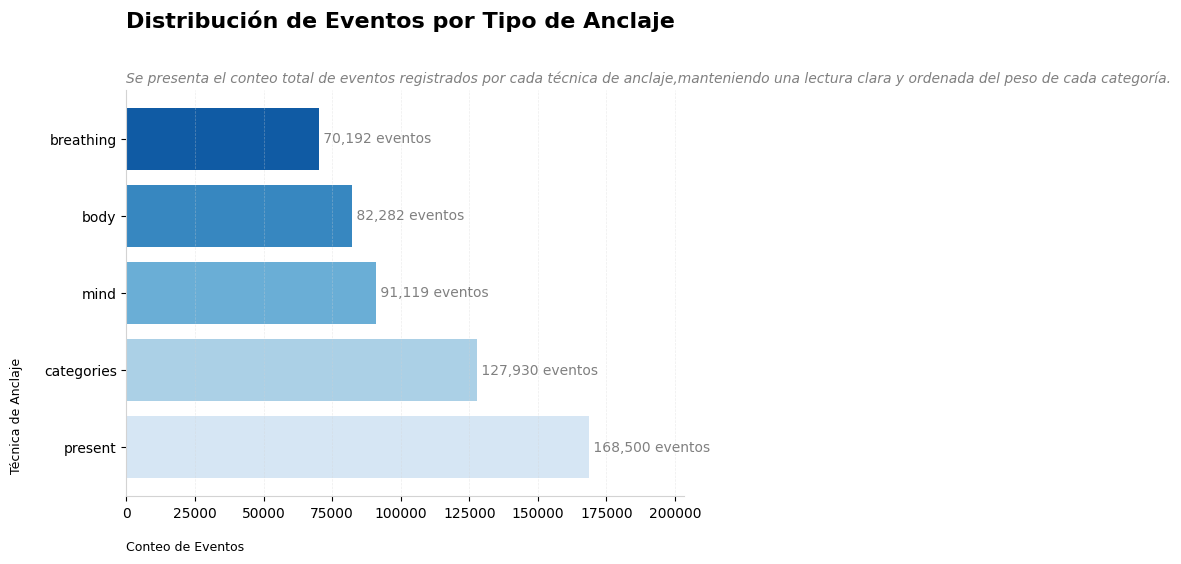

In [209]:
from seaborn.palettes import _ColorPalette
from typing import Any
import plotly.express as px

COLOR_POSITIVE = '#4A678C'
COLOR_NEGATIVE = '#731A06'
COLOR_WARNING = '#D78019'
COLOR_ATTENTION = '#0C1726'
COLOR_BG = '#F2F2F4'
COLOR_LINE = '#5A5A5C'
COLOR_GREY = '#A4A4A4'
WHITE = '#FFFFFF'
TECHNIQUE_COLORS = {
    'body': '#BA9B65',
    'breathing': '#D9043D',
    'categories': '#025940',
    'mind': '#6F7DA6',
    'present': COLOR_POSITIVE,
}
EVENT_COLORS = {
    'Grounding Started': COLOR_POSITIVE,
    'Grounding Ended': COLOR_NEGATIVE,
}


#? 3. Visualizacion de las clases

def generate_blue_palette(n: int) -> _ColorPalette:
    """
    Funcion encargada de generar una paleta de colores replicable en base de la paleta built-in de Blues de Seaborn
    y usando el parametro n para determinar cuantos colores generar y retornar para la visualizacion
    :param n: entero representativo de la cantidad de colores necesarios
    :return: listado de colores
    """
    return sns.color_palette('Blues', n)


def apply_dashboard_theme(fig, title: str, subtitle: str, height: int = 700, width: int = 1200):
    full_title = f"<b>{title}</b><br><i><span style='font-size:12px;font-weight:200;color:#666'>{subtitle}</span></i>"
    fig.update_layout(
        title={
            'text': full_title,
            'x': 0.02,
            'xanchor': 'left',
            'y': 0.92,
            'font': {'size': 16, 'family': 'Arial'},
        },
        autosize=False,
        width=width,
        height=height,
        margin=dict(l=120, r=120, b=70, t=140, pad=4),
        paper_bgcolor='white',
        plot_bgcolor='white',
        template='plotly_white',
    )
    return fig


def apply_dashboard_axes(
    fig,
    x_label: str | None = None,
    y_label: str | None = None,
    x_ticks=None,
    x_tick_labels=None,
    x_tick_angle: int = 30,
    x_axis_style: dict | None = None,
    y_axis_style: dict | None = None,
    x_axis_label_distance: float = -0.12,
    y_axis_label_distance: float = -0.12,
):
    default_x_style = {
        'showgrid': False,
        'title': '',
        'showline': True,
        'linewidth': 2,
        'linecolor': COLOR_LINE,
        'tickangle': x_tick_angle,
        'ticks': 'outside',
        'tickwidth': 2,
        'tickcolor': COLOR_LINE,
    }
    default_y_style = {
        'showgrid': False,
        'title': '',
        'showline': True,
        'linewidth': 2,
        'linecolor': COLOR_LINE,
        'ticks': 'outside',
        'tickwidth': 2,
        'tickcolor': COLOR_LINE,
    }

    x_style = default_x_style.copy()
    if x_axis_style:
        x_style.update(x_axis_style)
    if x_ticks is not None:
        x_style['tickvals'] = x_ticks
        x_style['ticktext'] = x_tick_labels if x_tick_labels else [str(t) for t in x_ticks]

    y_style = default_y_style.copy()
    if y_axis_style:
        y_style.update(y_axis_style)

    fig.update_xaxes(x_style)
    fig.update_yaxes(y_style)

    if x_label:
        fig.add_annotation(
            xref='paper',
            yref='paper',
            x=0,
            y=x_axis_label_distance,
            text=x_label,
            showarrow=False,
            xanchor='left',
            yanchor='bottom',
            font=dict(size=12, color=COLOR_LINE, family='Arial Black'),
        )
    if y_label:
        fig.add_annotation(
            xref='paper',
            yref='paper',
            x=y_axis_label_distance,
            y=0,
            text=y_label,
            showarrow=False,
            textangle=-90,
            xanchor='left',
            yanchor='bottom',
            font=dict(size=12, color=COLOR_LINE, family='Arial Black'),
        )
    return fig


def crear_barchart_storytelling(
        data: pd.DataFrame,
        x_axis_data: Any | str | pd.Series,
        x_axis_title: str,
        y_axis_data: Any | str | pd.Series,
        y_axis_title: str,
        fig_size: tuple[int, int],
        color_palette: Any,
        title: str,
        subtitle: str,
        orientation: str = 'horizontal',
        grid_axis: str = 'x',
        grid_color: str = 'lightgray',
        grid_linestyle: str = '--',
        grid_alpha: float = 0.4,
        visible_spines: set[str] = None,
        spine_colors: dict[str, str] = None,
        show_bar_labels: bool = True,
        bar_label_offset: float = 10,
        bar_label_fontsize: int = 10,
        bar_label_color: str = 'gray',
        bar_label_formatter: callable = None,
        hue: str = None,
        hue_order: list[str] = None,
        order: list[str] = None,
        show_x_axis: bool = True,
        show_y_axis: bool = True,
        x_tick_rotation: float = 0,
        y_tick_rotation: float = 0,
        show_legend: bool = False,
        legend_position: str = 'best',
        legend_title: str = None
) -> tuple[plt.Figure, plt.Axes]:
    """
    Funcion diseñada para generar una visualizacion orientada al storytelling con un titulo centrado, subtitulo con insight, y
    data programable para evitar la reescritura del codigo de las visualizaciones.
    """

    if visible_spines is None:
        visible_spines = {'bottom', 'left'}
    if spine_colors is None:
        spine_colors = {'bottom': 'lightgray', 'left': 'lightgray'}
    if bar_label_formatter is None:
        bar_label_formatter = lambda v: f'{v:,.0f}'

    fig, ax = plt.subplots(figsize=fig_size)
    if orientation == 'horizontal':
        if hue is not None:
            bars = sns.barplot(
                data=data,
                y=y_axis_data,
                x=x_axis_data,
                hue=hue,
                order=order,
                hue_order=hue_order,
                palette=color_palette,
                ax=ax,
            ).patches
        else:
            bars = ax.barh(data[y_axis_data], data[x_axis_data], color=color_palette)
    else:
        if hue is not None:
            bars = sns.barplot(
                data=data,
                x=x_axis_data,
                y=y_axis_data,
                hue=hue,
                order=order,
                hue_order=hue_order,
                palette=color_palette,
                ax=ax,
            ).patches
        else:
            bars = ax.bar(data[x_axis_data], data[y_axis_data], color=color_palette)

    ax.set_facecolor('white')
    ax.set_title(title, fontsize=16, fontweight='bold', loc='left', pad=45)
    ax.text(
        0.0,
        1.01,
        subtitle,
        transform=ax.transAxes,
        fontsize=10,
        fontstyle='italic',
        color='gray',
        va='bottom',
        ha='left'
    )

    if x_axis_title is not None and isinstance(x_axis_title, str):
        ax.set_xlabel(x_axis_title, fontdict={'fontsize': 9, 'fontweight': 'normal'}, labelpad=15, ha='left', x=0)
    if y_axis_title is not None and isinstance(y_axis_title, str):
        ax.set_ylabel(y_axis_title, fontdict={'fontsize': 9, 'fontweight': 'normal'}, labelpad=15, ha='center', va='bottom', y=0.2)

    if grid_axis == 'none':
        ax.grid(False)
    elif grid_axis == 'both':
        ax.grid(True, color=grid_color, linestyle=grid_linestyle, alpha=grid_alpha)
    else:
        ax.grid(False)
        ax.grid(True, axis=grid_axis, color=grid_color, linestyle=grid_linestyle, alpha=grid_alpha)

    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(spine in visible_spines)
        if spine in spine_colors:
            ax.spines[spine].set_color(spine_colors[spine])

    ax.xaxis.set_visible(show_x_axis)
    ax.yaxis.set_visible(show_y_axis)

    if x_tick_rotation != 0:
        ax.tick_params(axis='x', rotation=x_tick_rotation)
    if y_tick_rotation != 0:
        ax.tick_params(axis='y', rotation=y_tick_rotation)

    if show_bar_labels:
        if orientation == 'horizontal':
            ax.set_xlim(right=ax.get_xlim()[1] * 1.15)
        else:
            ax.set_ylim(top=ax.get_ylim()[1] * 1.15)

        for bar in bars:
            if orientation == 'horizontal':
                width = bar.get_width()
                if width != 0:
                    ax.text(
                        width,
                        bar.get_y() + bar.get_height() / 2,
                        bar_label_formatter(width),
                        color=bar_label_color,
                        va='center',
                        fontsize=bar_label_fontsize,
                    )
            else:
                height = bar.get_height()
                if height != 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        height,
                        bar_label_formatter(height),
                        color=bar_label_color,
                        ha='center',
                        fontsize=bar_label_fontsize,
                        va='bottom',
                    )

    if show_legend and hue is not None:
        ax.legend(title=legend_title, loc=legend_position)
    elif not show_legend:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    plt.tight_layout(pad=2.0)
    plt.show()


result = data_as_is['techniqueID'].value_counts().T.to_frame()
result.loc['Total',:] = result.sum(axis=0)

result_reset = result.drop(index='Total').reset_index().rename(columns={'techniqueID': 'Técnica'})
colors = generate_blue_palette(len(result_reset))

crear_barchart_storytelling(
    data=result_reset,
    y_axis_data='Técnica',
    x_axis_data='count',
    x_axis_title='Conteo de Eventos',
    y_axis_title='Técnica de Anclaje',
    show_y_axis=True,
    show_x_axis=True,
    bar_label_formatter=lambda v: f' {int(v):,.0f} eventos ',
    fig_size=(10, 6),
    color_palette=colors,
    orientation='horizontal',
    title='Distribución de Eventos por Tipo de Anclaje',
    subtitle='Se presenta el conteo total de eventos registrados por cada técnica de anclaje,'
             'manteniendo una lectura clara y ordenada del peso de cada categoría.'
)


En este caso notamos que la mayoría de los eventos del dataset se concentran directamente en tres técnicas de anclaje siendo estas **present, categories y mind** mientras que **body y breathing** son las clases con menores conteos de registros de todo el dataset. En paralelo con esta distribución, es importante notar qeu las categorías más altas, especificamente **present** corresponde a aquella categoría con mayor cantidad de registros de terminación que inicio, lo que indica que la categoría está modificando los datos de eventos iniciados por usuarios dado que aparece en varios registros adicionales o duplicados, lo que puede afectar la precisión y confiabilidad de los resultados obtenidos a partir de estos datos. Por otro lado, las categorías con menor cantidad de registros, específicamente **body y breathing** corresponden a aquellas categorías con mayor cantidad de registros de inicio que terminación, lo que indica que estas categorías están modificando los datos de eventos terminados por usuarios dado que aparecen en varios registros adicionales o huérfanos, lo que también puede afectar la precisión y confiabilidad de los resultados obtenidos a partir de estos datos.

En general, el registro de datos se ve afectado mayoritariamente por este error de registro de datos correspondiente a la paridad de inicio y fin de actividades, dado que al tener sea más inicios o más finalizaciones, los datos de esas categorías de anclaje presentan en el dataset una representación que no es real, dado que los datos se han inflado en cualquier dirección afectando la veracidad de los datos.

#### Exploración de date

Para esta sección, exploraremos los registros mediante una conversión en data to explore basado en la transformación de la columna de date a dos columnas, una para fecha y otra para hora, y luego de esto explorar la distribución de horas y la distribución de fechas. Luego usaremos estos datos para realizar un análisis de conteo basado en la distribución de  los eventos de terminación e inicio de event, y los tipos de anclaje por horas del día, por día y por semana.


Para esta subseccion se trabaja sobre una copia del dataset para no alterar los datos originales. Primero se separa la columna date en campos base y luego se construyen tres agregaciones: por fecha, por hora y por dia de semana.


In [210]:
#? 1. Convertimos date a datetime y derivamos campos base para analisis
data_to_explore['date_dt'] = pd.to_datetime(data_to_explore['date'], format='%m/%d/%Y %H:%M', errors='coerce')
data_to_explore['fecha'] = data_to_explore['date_dt'].dt.date
data_to_explore['hora'] = data_to_explore['date_dt'].dt.hour
data_to_explore['anio'] = data_to_explore['date_dt'].dt.year
data_to_explore['mes_num'] = data_to_explore['date_dt'].dt.month
data_to_explore['nombre_mes'] = data_to_explore['mes_num'].map(
    {1: 'Enero',
     2: 'Febrero',
     3: 'Marzo',
     4: 'Abril',
     5: 'Mayo',
     6: 'Junio',
     7: 'Julio',
     8: 'Agosto',
     9: 'Septiembre',
     10: 'Octubre',
     11: 'Noviembre',
     12: 'Diciembre'})
data_to_explore['dia_semana_num'] = data_to_explore['date_dt'].dt.dayofweek
data_to_explore['dia_semana'] = data_to_explore['dia_semana_num'].map(
    {
        0: 'Lunes',
        1: 'Martes',
        2: 'Miercoles',
        3: 'Jueves',
        4: 'Viernes',
        5: 'Sabado',
        6: 'Domingo'})

data_to_explore

,Unnamed: 0,id,event,techniqueID,date,date_dt,fecha,hora,anio,mes_num,nombre_mes,dia_semana_num,dia_semana
0,1,2719,Grounding Started,present,1/12/2022 14:06,2022-01-12 14:06:00,2022-01-12,14,2022,1,Enero,2,Miercoles
1,2,2720,Grounding Ended,present,1/12/2022 14:06,2022-01-12 14:06:00,2022-01-12,14,2022,1,Enero,2,Miercoles
2,3,2721,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,Enero,2,Miercoles
3,4,2722,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,Enero,2,Miercoles
4,5,2723,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,Enero,2,Miercoles
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540018,1323286,1326004,Grounding Ended,present,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,Marzo,2,Miercoles
540019,1323287,1326005,Grounding Ended,present,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,Marzo,2,Miercoles
540020,1323292,1326010,Grounding Ended,categories,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,Marzo,2,Miercoles
540021,1323299,1326017,Grounding Started,body,3/16/2022 16:46,2022-03-16 16:46:00,2022-03-16,16,2022,3,Marzo,2,Miercoles


In [211]:
#? 2. Agregamos los eventos por fecha para ver la carga diaria
agrupacion_fecha = data_to_explore.groupby(['fecha', 'event']).size().unstack(fill_value=0).sort_index()
agrupacion_fecha['Total'] = agrupacion_fecha.sum(axis=1)
agrupacion_fecha.sort_values('Total', ascending=False).head(10)

event,Grounding Ended,Grounding Started,Total
fecha,,,
2022-01-23,9298,9319,18617
2022-01-24,7552,7615,15167
2022-01-25,6668,6716,13384
2022-01-22,5689,5674,11363
2022-01-26,5618,5552,11170
2022-03-07,5249,5138,10387
2022-03-06,5178,5134,10312
2022-01-27,4938,4800,9738
2022-02-07,4726,4701,9427


In [212]:
#? Visualizacion con Plotly de la agrupacion por fecha con drill-down Month -> Day -> Hour
agrupacion_fecha_plot = agrupacion_fecha.reset_index().melt(
    id_vars='fecha', value_vars=['Grounding Started', 'Grounding Ended'],
    var_name='event', value_name='conteo'
)
agrupacion_fecha_plot['fecha'] = pd.to_datetime(agrupacion_fecha_plot['fecha'])

#? Preparar las tres agregaciones
# Mes
mes_df = agrupacion_fecha_plot.copy()
mes_df['periodo'] = mes_df['fecha'].dt.to_period('M').dt.to_timestamp()
mes_agg = mes_df.groupby(['periodo', 'event'])['conteo'].sum().reset_index()
mes_agg['label'] = mes_agg['periodo'].dt.strftime('%B %Y')

# Dia
dia_df = agrupacion_fecha_plot.copy()
dia_df['periodo'] = dia_df['fecha'].dt.normalize()
dia_agg = dia_df.groupby(['periodo', 'event'])['conteo'].sum().reset_index()
dia_agg['label'] = dia_agg['periodo'].dt.strftime('%d %b %Y')

# Hora (si la fecha original tiene componente horario, se agrupa por hora)
hora_df = agrupacion_fecha_plot.copy()
hora_df['periodo'] = hora_df['fecha'].dt.floor('h')
hora_agg = hora_df.groupby(['periodo', 'event'])['conteo'].sum().reset_index()
hora_agg['label'] = hora_agg['periodo'].dt.strftime('%d %b %Y %H:%M')

events = ['Grounding Started', 'Grounding Ended']
fig = go.Figure()

#? Agregar traces para cada nivel: 0-1 = mes, 2-3 = dia, 4-5 = hora
for i, (agg, level) in enumerate([(mes_agg, 'mes'), (dia_agg, 'dia'), (hora_agg, 'hora')]):
    for event in events:
        event_data = agg[agg['event'] == event].sort_values('periodo')
        fig.add_trace(go.Scatter(
            x=event_data['label'],
            y=event_data['conteo'],
            mode='lines+markers',
            name=event,
            legendgroup=event,
            showlegend=True,
            visible=(i == 0),
            line=dict(color=EVENT_COLORS.get(event)),
            marker=dict(color=EVENT_COLORS.get(event)),
            hovertemplate='%{x}<br>%{y:,.0f} eventos<extra>' + event + '</extra>',
        ))

#? Definir visibilidad por nivel (2 traces por nivel x 3 niveles = 6 traces)
def make_visibility(active_level):
    vis = [False] * 6
    base = active_level * 2
    vis[base] = True
    vis[base + 1] = True
    return vis

fig.update_layout(
    updatemenus=[
        dict(
            type='buttons',
            direction='right',
            x=0.5, xanchor='center',
            y=-0.15, yanchor='top',
            buttons=[
                dict(label='▶ Mes', method='update',
                     args=[{'visible': make_visibility(0)},
                           {'xaxis': {'title': 'Mes', 'showgrid': False, 'showline': True,
                                      'linecolor': COLOR_LINE, 'linewidth': 2,
                                      'ticks': 'outside', 'tickcolor': COLOR_LINE}}]),
                dict(label='▶ Día', method='update',
                     args=[{'visible': make_visibility(1)},
                           {'xaxis': {'title': 'Día', 'showgrid': False, 'showline': True,
                                      'linecolor': COLOR_LINE, 'linewidth': 2,
                                      'ticks': 'outside', 'tickcolor': COLOR_LINE,
                                      'tickangle': -45}}]),
                dict(label='▶ Hora', method='update',
                     args=[{'visible': make_visibility(2)},
                           {'xaxis': {'title': 'Hora', 'showgrid': False, 'showline': True,
                                      'linecolor': COLOR_LINE, 'linewidth': 2,
                                      'ticks': 'outside', 'tickcolor': COLOR_LINE,
                                      'tickangle': -45}}]),
            ],
        )
    ],
)

apply_dashboard_theme(
    fig,
    'Conteo por fecha y evento',
    'La serie temporal permite comparar aperturas y cierres. Use los botones para navegar entre vista mensual, diaria y horaria.',
    height=700,
)
apply_dashboard_axes(fig, x_label='Mes', y_label='Conteo de eventos', x_tick_angle=0, y_axis_style={'tickformat': ',.0f'})
fig.update_layout(
    hovermode='x unified',
    legend=dict(title='Evento', orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(b=120),
)
fig.show()


In [213]:
#? 3. Agregamos los eventos por hora para detectar concentracion intradia
agrupacion_hora = data_to_explore.groupby(['hora', 'event']).size().unstack(fill_value=0).sort_index()
agrupacion_hora['Total'] = agrupacion_hora.sum(axis=1)
agrupacion_hora


event,Grounding Ended,Grounding Started,Total
hora,,,
0,20193,19476,39669
1,14595,14597,29192
2,9138,9236,18374
3,4519,4495,9014
4,2781,2952,5733
5,2316,2377,4693
6,2664,2740,5404
7,3865,3994,7859
8,5288,5094,10382


In [214]:
#? Visualizacion con Plotly de la agrupacion por hora
agrupacion_hora_plot = agrupacion_hora.reset_index().melt(id_vars='hora', value_vars=['Grounding Started', 'Grounding Ended'], var_name='event', value_name='conteo')

fig = px.bar(
    agrupacion_hora_plot,
    x='hora',
    y='conteo',
    color='event',
    barmode='group',
    category_orders={'hora': list(range(24))},
    color_discrete_map=EVENT_COLORS,
    title='Conteo por hora y evento'
)
apply_dashboard_theme(
    fig,
    'Conteo por hora y evento',
    'Las horas concentran la actividad en bloques claros y ayudan a identificar cuándo se abren y cierran más registros.',
    height=650,
)
apply_dashboard_axes(fig, x_label='Hora del día', y_label='Conteo de eventos', x_ticks=list(range(24)), x_tick_labels=[str(h) for h in range(24)], x_tick_angle=0, y_axis_style={'tickformat': ',.0f'})
fig.update_layout(hovermode='x', legend=dict(title='Evento', orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
fig.show()


In [215]:
#? 4. Agregamos los eventos por dia de la semana para ver patrones semanales
orden_dias = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
agrupacion_dia_semana = data_to_explore.groupby(['dia_semana', 'event']).size().unstack(fill_value=0).reindex(orden_dias).fillna(0).astype(int)
agrupacion_dia_semana['Total'] = agrupacion_dia_semana.sum(axis=1)
agrupacion_dia_semana


event,Grounding Ended,Grounding Started,Total
dia_semana,,,
Lunes,42174,41359,83533
Martes,39858,39000,78858
Miercoles,37043,36574,73617
Jueves,36397,35655,72052
Viernes,35563,35022,70585
Sabado,37385,36590,73975
Domingo,44067,43336,87403


In [216]:
#? Visualizacion con Plotly de la agrupacion por dia de la semana
agrupacion_dia_semana_plot = agrupacion_dia_semana.reset_index().melt(id_vars='dia_semana', value_vars=['Grounding Started', 'Grounding Ended'], var_name='event', value_name='conteo')

fig = px.bar(
    agrupacion_dia_semana_plot,
    x='dia_semana',
    y='conteo',
    color='event',
    barmode='group',
    category_orders={'dia_semana': orden_dias},
    color_discrete_map=EVENT_COLORS,
    title='Conteo por dia de la semana y evento'
)
apply_dashboard_theme(
    fig,
    'Conteo por día de la semana y evento',
    'La distribución semanal ayuda a leer qué días concentran más actividad y si los cierres siguen el mismo patrón que los inicios.',
    height=650,
)
apply_dashboard_axes(fig, x_label='Día de la semana', y_label='Conteo de eventos', x_tick_angle=0, y_axis_style={'tickformat': ',.0f'})
fig.update_layout(hovermode='x', legend=dict(title='Evento', orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
fig.show()


In [217]:
#? 5. Agrupamos por mes y techniqueID para contar eventos por tipo
orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
agrupacion_mes = data_to_explore.groupby(['mes_num', 'nombre_mes', 'techniqueID', 'event']).size().unstack(fill_value=0).reset_index().sort_values(['mes_num', 'techniqueID'])
agrupacion_mes


event,mes_num,nombre_mes,techniqueID,Grounding Ended,Grounding Started
0,1,Enero,body,11870,17127
1,1,Enero,breathing,10494,13062
2,1,Enero,categories,14616,29859
3,1,Enero,mind,12095,18889
4,1,Enero,present,45351,12812
5,2,Febrero,body,13563,20183
6,2,Febrero,breathing,12899,16434
7,2,Febrero,categories,17102,36001
8,2,Febrero,mind,15163,23266
9,2,Febrero,present,53913,15505


In [218]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

#? Visualizacion con Plotly de la agrupacion por mes y techniqueID
agrupacion_mes_plot = agrupacion_mes.melt(
    id_vars=['mes_num', 'nombre_mes', 'techniqueID'],
    value_vars=['Grounding Started', 'Grounding Ended'],
    var_name='event', value_name='conteo'
)

#? Filtrar solo hasta marzo (mes_num <= 3)
agrupacion_mes_plot = agrupacion_mes_plot[agrupacion_mes_plot['mes_num'] <= 3]
orden_meses_filtrado = [m for m in orden_meses if m in agrupacion_mes_plot['nombre_mes'].values]

events = ['Grounding Started', 'Grounding Ended']
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[f'<b>{e}</b>' for e in events],
    horizontal_spacing=0.15
)

techniques = agrupacion_mes_plot['techniqueID'].unique()
shown_legends = set()

for col_idx, event in enumerate(events, start=1):
    event_data = agrupacion_mes_plot[agrupacion_mes_plot['event'] == event]
    for tech in techniques:
        tech_data = (event_data[event_data['techniqueID'] == tech]
                     .set_index('nombre_mes')
                     .reindex(orden_meses_filtrado)
                     .reset_index())
        show_legend = tech not in shown_legends
        shown_legends.add(tech)
        fig.add_trace(
            go.Bar(
                x=tech_data['nombre_mes'],
                y=tech_data['conteo'],
                name=tech,
                legendgroup=tech,
                showlegend=show_legend,
                marker_color=TECHNIQUE_COLORS.get(tech),
            ),
            row=1, col=col_idx
        )

fig.update_layout(barmode='group')
apply_dashboard_theme(
    fig,
    'Conteo por mes, techniqueID y evento',
    'El corte mensual muestra qué técnicas dominan el volumen y cómo cambia la proporción entre inicios y cierres.',
    height=680,
)
fig.update_layout(legend_title='Técnica', hovermode='closest')
fig.update_xaxes(title='Mes', showgrid=False, showline=True, linecolor=COLOR_LINE, linewidth=2, ticks='outside', tickcolor=COLOR_LINE)
fig.update_yaxes(title='Conteo', showgrid=False, showline=True, linecolor=COLOR_LINE, linewidth=2, ticks='outside', tickcolor=COLOR_LINE, tickformat=',.0f')
fig.show()


In [219]:
#? 6. Agrupamos por dia de la semana y techniqueID para contar eventos por tipo
orden_dias = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
agrupacion_dia_semana_tech = data_to_explore.groupby(['dia_semana_num', 'dia_semana', 'techniqueID', 'event']).size().unstack(fill_value=0).reset_index().sort_values(['dia_semana_num', 'techniqueID'])
agrupacion_dia_semana_tech


event,dia_semana_num,dia_semana,techniqueID,Grounding Ended,Grounding Started
0,0,Lunes,body,5096,7580
1,0,Lunes,breathing,4830,6073
2,0,Lunes,categories,6239,13370
3,0,Lunes,mind,5595,8518
4,0,Lunes,present,20414,5818
5,1,Martes,body,4801,7188
6,1,Martes,breathing,4493,5701
7,1,Martes,categories,6138,12601
8,1,Martes,mind,5235,8035
9,1,Martes,present,19191,5475


In [220]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

#? Visualizacion con Plotly de la agrupacion por dia de la semana y techniqueID
agrupacion_dia_semana_tech_plot = agrupacion_dia_semana_tech.melt(
    id_vars=['dia_semana_num', 'dia_semana', 'techniqueID'],
    value_vars=['Grounding Started', 'Grounding Ended'],
    var_name='event', value_name='conteo'
)

events = ['Grounding Started', 'Grounding Ended']
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[f'<b>{e}</b>' for e in events],
    horizontal_spacing=0.15
)

techniques = agrupacion_dia_semana_tech_plot['techniqueID'].unique()
shown_legends = set()

for col_idx, event in enumerate(events, start=1):
    event_data = agrupacion_dia_semana_tech_plot[agrupacion_dia_semana_tech_plot['event'] == event]
    for tech in techniques:
        tech_data = event_data[event_data['techniqueID'] == tech].set_index('dia_semana').reindex(orden_dias).reset_index()
        show_legend = tech not in shown_legends
        shown_legends.add(tech)
        fig.add_trace(
            go.Scatter(
                x=tech_data['dia_semana'],
                y=tech_data['conteo'],
                mode='lines+markers',
                name=tech,
                legendgroup=tech,
                showlegend=show_legend,
                line=dict(color=TECHNIQUE_COLORS.get(tech)),
            ),
            row=1, col=col_idx
        )

apply_dashboard_theme(
    fig,
    'Conteo por día de la semana, techniqueID y evento',
    'La lectura por día permite ver qué técnicas sostienen más actividad y dónde aparece el desbalance entre inicio y cierre.',
    height=680,
)
fig.update_layout(legend_title='Técnica', hovermode='closest')
fig.update_xaxes(title='Día de la semana', showgrid=False, showline=True, linecolor=COLOR_LINE, linewidth=2, ticks='outside', tickcolor=COLOR_LINE)
fig.update_yaxes(title='Conteo', showgrid=False, showline=True, linecolor=COLOR_LINE, linewidth=2, ticks='outside', tickcolor=COLOR_LINE, tickformat=',.0f')
fig.show()


## Sección III: Preprocesamiento de Datos Iniciales

En esta sección se trabajará para aplicar las medidas de limpieza de datos definidas en la sección I, aplicando las correcciones necesarias para el análisis, como la eliminación de columnas no útiles, la derivación de columnas adicionales para el análisis, y la corrección de valores atípicos o nulos en base a las métricas definidas en la sección I.

In [221]:
#? 1. Eliminamos columnas de identificación que no aportan valor analítico
columnas_a_eliminar = ['Unnamed: 0', 'id']
data_cleaned = data_cleaned.drop(columns=columnas_a_eliminar, errors='ignore')

In [222]:
#? 2. Convertimos la columna `date` a datetime para derivar atributos temporales
#? El formato observado en el cuaderno es mm/dd/yyyy hh:mm
data_cleaned['date_dt'] = pd.to_datetime(
    data_cleaned['date'],
    format='%m/%d/%Y %H:%M',
    errors='coerce'
)

dias_semana_es = {
    0: 'lunes',
    1: 'martes',
    2: 'miércoles',
    3: 'jueves',
    4: 'viernes',
    5: 'sábado',
    6: 'domingo',
}
meses_es = {
    1: 'enero',
    2: 'febrero',
    3: 'marzo',
    4: 'abril',
    5: 'mayo',
    6: 'junio',
    7: 'julio',
    8: 'agosto',
    9: 'septiembre',
    10: 'octubre',
    11: 'noviembre',
    12: 'diciembre',
}

#? 2.1 Derivamos las columnas temporales solicitadas
#? `fecha` mantiene solo la fecha; `hora` conserva la hora del evento
#? y el resto de columnas facilitan agregaciones por mes y día de semana
data_cleaned['fecha'] = data_cleaned['date_dt'].dt.date
data_cleaned['hora'] = data_cleaned['date_dt'].dt.hour.astype('Int64')
data_cleaned['anio'] = data_cleaned['date_dt'].dt.year.astype('Int64')
data_cleaned['mes_num'] = data_cleaned['date_dt'].dt.month.astype('Int64')
data_cleaned['nombre_mes'] = data_cleaned['mes_num'].map(meses_es)
data_cleaned['dia_semana_num'] = data_cleaned['date_dt'].dt.dayofweek.astype('Int64')
data_cleaned['dia_semana'] = data_cleaned['dia_semana_num'].map(dias_semana_es)

data_cleaned

,event,techniqueID,date,date_dt,fecha,hora,anio,mes_num,nombre_mes,dia_semana_num,dia_semana
0,Grounding Started,present,1/12/2022 14:06,2022-01-12 14:06:00,2022-01-12,14,2022,1,enero,2,miércoles
1,Grounding Ended,present,1/12/2022 14:06,2022-01-12 14:06:00,2022-01-12,14,2022,1,enero,2,miércoles
2,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,enero,2,miércoles
3,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,enero,2,miércoles
4,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,enero,2,miércoles
...,...,...,...,...,...,...,...,...,...,...,...
540018,Grounding Ended,present,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,marzo,2,miércoles
540019,Grounding Ended,present,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,marzo,2,miércoles
540020,Grounding Ended,categories,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,marzo,2,miércoles
540021,Grounding Started,body,3/16/2022 16:46,2022-03-16 16:46:00,2022-03-16,16,2022,3,marzo,2,miércoles


In [223]:
#? 3. Aplicamos One-hot encoding de `event`.
#? Se conservan las columnas originales para no romper el análisis posterior,
#? pero se agregan variables binarias para facilitar agrupaciones y cruces.
event_dummies = pd.get_dummies(data_cleaned['event'], dtype='int64')
data_cleaned = pd.concat([data_cleaned, event_dummies], axis=1)

data_cleaned

,event,techniqueID,date,date_dt,fecha,hora,anio,mes_num,nombre_mes,dia_semana_num,dia_semana,Grounding Ended,Grounding Started
0,Grounding Started,present,1/12/2022 14:06,2022-01-12 14:06:00,2022-01-12,14,2022,1,enero,2,miércoles,0,1
1,Grounding Ended,present,1/12/2022 14:06,2022-01-12 14:06:00,2022-01-12,14,2022,1,enero,2,miércoles,1,0
2,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,enero,2,miércoles,1,0
3,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,enero,2,miércoles,1,0
4,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,enero,2,miércoles,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540018,Grounding Ended,present,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,marzo,2,miércoles,1,0
540019,Grounding Ended,present,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,marzo,2,miércoles,1,0
540020,Grounding Ended,categories,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,marzo,2,miércoles,1,0
540021,Grounding Started,body,3/16/2022 16:46,2022-03-16 16:46:00,2022-03-16,16,2022,3,marzo,2,miércoles,0,1


## Sección IV: Análisis de Datos

En esta sección se trabajará con un análisis de datos en base de agrupaciones y visualizaciones para identificar patrones y responder a las preguntas de negocio. Dado que no tenemos una cantidad significativa de datos numéricos para realizar un análisis estadísticos, se considerará, con vista a los resultados de agregaciones y visualizaciones la posibilidad de realizar pruebas de hipótesis estadísticas para evaluar la significancia de los resultados obtenidos, lo que podría ser útil para identificar patrones significativos en los datos y evitar conclusiones erróneas basadas en patrones aleatorios o ruido en los datos.

### Frecuencia de Uso de Cada Técnica de Anclaje

In [224]:
#? 1. Exploracion de la distribucion de eventos de inicio y finalizacion por cada tipo de anclaje
result = data_as_is.groupby(by='techniqueID')['event'].value_counts(sort=True)


conteo_y_proporcion_de_eventos_por_tecnica = pd.DataFrame(
    {
        "conteo": result,
        "proporcion": result.groupby(level=0).transform(lambda x: x /x.sum()).apply(lambda v: f"{round(v*100,2)} %")
    },
    index = result.index
)

conteo_y_proporcion_de_eventos_por_tecnica

conteo proporcion
techniqueID event                               
body        Grounding Started   48989    59.54 %
            Grounding Ended     33293    40.46 %
breathing   Grounding Started   39173    55.81 %
            Grounding Ended     31019    44.19 %
categories  Grounding Started   86433    67.56 %
            Grounding Ended     41497    32.44 %
mind        Grounding Started   55539    60.95 %
            Grounding Ended     35580    39.05 %
present     Grounding Ended    131098     77.8 %
            Grounding Started   37402     22.2 %

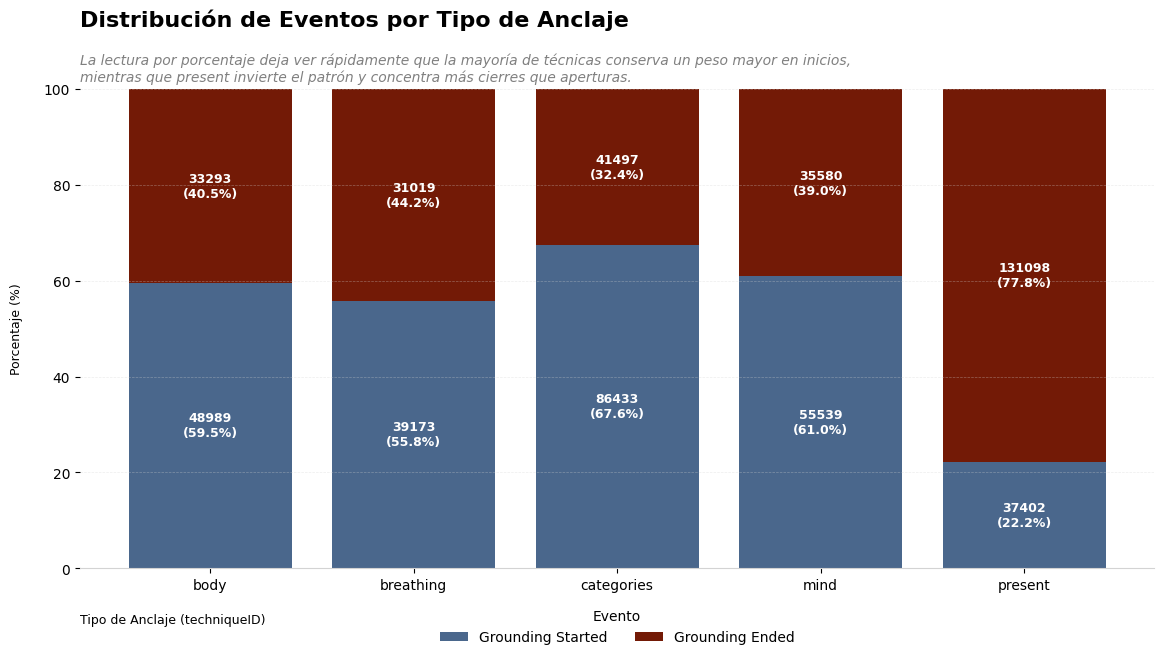

In [225]:
#? 1.1 Preparacion de datos para el stacked bar chart
stacked_data = data_as_is.groupby('techniqueID')['event'].value_counts().unstack(fill_value=0)
stacked_data = stacked_data.reindex(columns=['Grounding Started', 'Grounding Ended'])
stacked_pct = stacked_data.div(stacked_data.sum(axis=1), axis=0) * 100

#? 1.2 Visualizacion de distribucion de eventos por tipo de anclaje
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#4A678C', '#731A06']

bottom = np.zeros(len(stacked_pct))
for i, col in enumerate(stacked_pct.columns):
    bars = ax.bar(stacked_pct.index, stacked_pct[col], bottom=bottom, color=colors[i], label=col)
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:
            count = stacked_data.iloc[j][col]
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + height / 2,
                f'{count}\n({height:.1f}%)',
                ha='center',
                va='center',
                fontsize=9,
                color='white',
                fontweight='bold'
            )
    bottom += stacked_pct[col].values

#? Titulo y subtitulo storytelling
ax.set_title(
    'Distribución de Eventos por Tipo de Anclaje',
    fontsize=16,
    fontweight='bold',
    loc='left',
    pad=45
)
subtitle = (
    'La lectura por porcentaje deja ver rápidamente que la mayoría de técnicas conserva un peso mayor en inicios,\n'
    'mientras que present invierte el patrón y concentra más cierres que aperturas.'
)
ax.text(
    0.0,
    1.01,
    subtitle,
    transform=ax.transAxes,
    fontsize=10,
    fontstyle='italic',
    color='gray',
    va='bottom',
    ha='left'
)

ax.set_xlabel('Tipo de Anclaje (techniqueID)', fontdict={'fontsize': 9}, labelpad=15, ha='left', x=0)
ax.set_ylabel('Porcentaje (%)', fontdict={'fontsize': 9}, labelpad=15)
ax.set_ylim(0, 100)

#? Estilo minimalista
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('lightgray')
ax.grid(True, axis='y', color='lightgray', linestyle='--', alpha=0.4)
ax.legend(title='Evento', loc='upper center', frameon=False, bbox_to_anchor=(0.5, -0.06), ncol=2)

plt.tight_layout(pad=2.0)
plt.show()

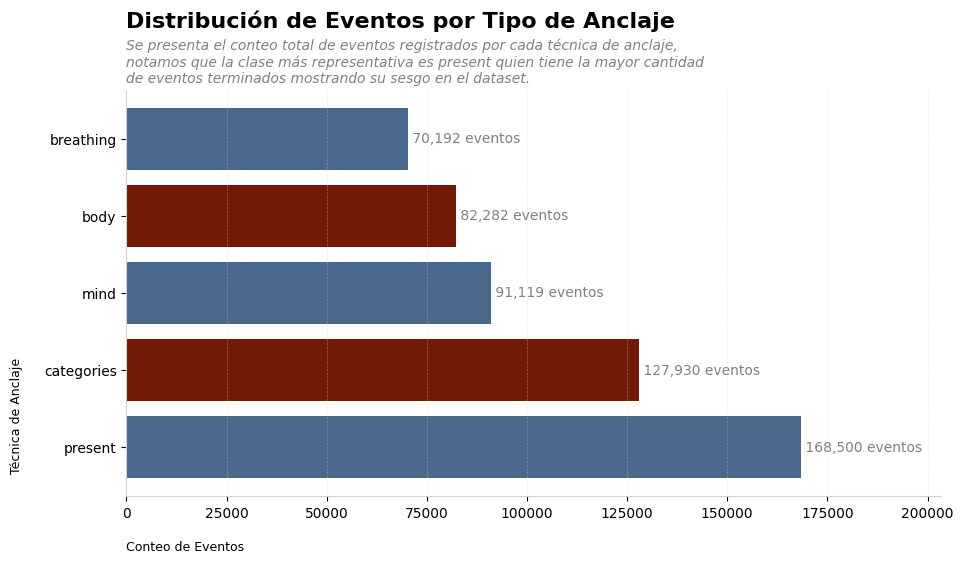

In [226]:
#? 2.1 Exploracion visual del conteo de registros de cada tecnica de anclaje en general
crear_barchart_storytelling(
    data=result_reset,
    y_axis_data='Técnica',
    x_axis_data='count',
    x_axis_title='Conteo de Eventos',
    y_axis_title='Técnica de Anclaje',
    show_y_axis=True,
    show_x_axis=True,
    bar_label_formatter=lambda v: f' {int(v):,.0f} eventos ',
    fig_size=(10, 6),
    color_palette=colors,
    orientation='horizontal',
    title='Distribución de Eventos por Tipo de Anclaje',
    subtitle='Se presenta el conteo total de eventos registrados por cada técnica de anclaje,\n'
             'notamos que la clase más representativa es present quien tiene la mayor cantidad\nde eventos terminados mostrando su sesgo en el dataset.'
)

In [227]:
#? 3. Exploracion de agregacion diaria de la cantidad de eventos disparados por tipo de anclaje y segmentados por tipo de evento

from plotly.subplots import make_subplots
import plotly.graph_objects as go

#? Agregacion directa desde el dataframe con columnas OHE
agrupacion_dia_semana_tech = (
    data_cleaned.groupby(['dia_semana_num', 'dia_semana', 'techniqueID'])[['Grounding Started', 'Grounding Ended']]
    .sum()
    .reset_index()
)

events = ['Grounding Started', 'Grounding Ended']
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[f'<b>{e}</b>' for e in events],
    horizontal_spacing=0.15
)

techniques = agrupacion_dia_semana_tech['techniqueID'].unique()
shown_legends = set()

for col_idx, event in enumerate(events, start=1):
    for tech in techniques:
        tech_data = (agrupacion_dia_semana_tech[agrupacion_dia_semana_tech['techniqueID'] == tech])
        show_legend = tech not in shown_legends
        shown_legends.add(tech)
        fig.add_trace(
            go.Scatter(
                x=tech_data['dia_semana'],
                y=tech_data[event],
                mode='lines+markers',
                name=tech,
                legendgroup=tech,
                showlegend=show_legend,
                line=dict(color=TECHNIQUE_COLORS.get(tech)),
                customdata=techniques,
                hovertemplate=f"""
                %{{x}}<br>Eventos:%{{y:,.0f}}<br>Técnica: {tech}<extra></extra>
                """
            ),
            row=1, col=col_idx
        )

apply_dashboard_theme(
    fig,
    'Conteo por día de la semana, techniqueID y evento',
    'La lectura por día permite ver qué técnicas sostienen más actividad y dónde aparece el desbalance entre inicio y cierre.',
    height=680,
)
apply_dashboard_axes(fig, x_label='Dia de la Semana', y_label='Conteo',x_axis_label_distance=-0.2,y_axis_label_distance=-0.05)
fig.update_layout(legend_title='Técnica', hovermode='closest')

fig.show()


In [228]:
#? 4. Exploracion visual de la distribucion de eventos por hora del dia (agregada como manana, tarde o noche) y tipo de evento

from plotly.subplots import make_subplots
import plotly.graph_objects as go

#? 4.1 Crear columna time_of_day_range basada en una categorizacion horaria
def categorize_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Mañana'
    elif 12 <= hour < 19:
        return 'Tarde'
    else:
        return 'Noche'

#? 4.2 Creamos la columna en base de un apply a la hora
data_cleaned['time_of_day_range'] = data_cleaned['hora'].apply(categorize_time_of_day)

#? Orden para el eje x
orden_tiempo = ['Mañana', 'Tarde', 'Noche']

#? Agregacion por rango de tiempo y techniqueID
agrupacion_tiempo_tech = (
    data_cleaned.groupby(['time_of_day_range', 'techniqueID'])[['Grounding Started', 'Grounding Ended']]
    .sum()
    .reset_index()
)

events = ['Grounding Started', 'Grounding Ended']
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[f'<b>{e}</b>' for e in events],
    horizontal_spacing=0.15
)

techniques = agrupacion_tiempo_tech['techniqueID'].unique()
shown_legends = set()

for col_idx, event in enumerate(events, start=1):
    for tech in techniques:
        tech_data = (agrupacion_tiempo_tech[agrupacion_tiempo_tech['techniqueID'] == tech]
                     .set_index('time_of_day_range')
                     .reindex(orden_tiempo)
                     .reset_index())
        show_legend = tech not in shown_legends
        shown_legends.add(tech)
        fig.add_trace(
            go.Scatter(
                x=tech_data['time_of_day_range'],
                y=tech_data[event],
                mode='lines+markers',
                name=tech,
                legendgroup=tech,
                showlegend=show_legend,
                line=dict(color=TECHNIQUE_COLORS.get(tech)),
                hovertemplate=f"%{{x}}<br>Eventos: %{{y:,.0f}}<br>Técnica: {tech}<extra></extra>"
            ),
            row=1, col=col_idx
        )

apply_dashboard_theme(
    fig,
    'Conteo por rango horario, techniqueID y evento',
    'La distribución por mañana, tarde y noche revela los momentos del día con mayor actividad para cada técnica.',
    height=680,
)
apply_dashboard_axes(fig, x_label='Rango Horario', y_label='Conteo', x_axis_label_distance=-0.2, y_axis_label_distance=-0.05)
fig.update_layout(legend_title='Técnica', hovermode='closest')
fig.show()


In [229]:
#? 2. Visualizacion por hora del dia (0-23) segmentada por techniqueID

from plotly.subplots import make_subplots
import plotly.graph_objects as go

#? Agregacion por hora y techniqueID
agrupacion_hora_tech = (
    data_cleaned.groupby(['hora', 'techniqueID'])[['Grounding Started', 'Grounding Ended']]
    .sum()
    .reset_index()
)

events = ['Grounding Started', 'Grounding Ended']
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[f'<b>{e}</b>' for e in events],
    horizontal_spacing=0.15
)

techniques = agrupacion_hora_tech['techniqueID'].unique()
shown_legends = set()

for col_idx, event in enumerate(events, start=1):
    for tech in techniques:
        tech_data = (agrupacion_hora_tech[agrupacion_hora_tech['techniqueID'] == tech]
                     .set_index('hora')
                     .reindex(range(24))
                     .reset_index()
                     .fillna(0))
        show_legend = tech not in shown_legends
        shown_legends.add(tech)
        fig.add_trace(
            go.Scatter(
                x=tech_data['hora'],
                y=tech_data[event],
                mode='lines+markers',
                name=tech,
                legendgroup=tech,
                showlegend=show_legend,
                line=dict(color=TECHNIQUE_COLORS.get(tech)),
                hovertemplate=f"Hora: %{{x}}:00<br>Eventos: %{{y:,.0f}}<br>Técnica: {tech}<extra></extra>"
            ),
            row=1, col=col_idx
        )

apply_dashboard_theme(
    fig,
    'Conteo por hora del día, techniqueID y evento',
    'La tendencia horaria muestra los picos de actividad a lo largo del día para cada técnica de anclaje.',
    height=680,
)
apply_dashboard_axes(fig, x_label='Hora del Día', y_label='Conteo', x_axis_label_distance=-0.2, y_axis_label_distance=-0.05)
fig.update_layout(legend_title='Técnica', hovermode='closest')
fig.update_xaxes(tickmode='linear', tick0=0, dtick=2)
fig.show()


### Porcentaje de Finalizacion de Tecnicas por Usuario


In [230]:
import plotly.graph_objects as go

usuarios_por_tecnica = data_cleaned.groupby('techniqueID').agg({
    'Grounding Started': 'sum',
    'Grounding Ended': 'sum'
}).reset_index()

fig = go.Figure()

for tech in usuarios_por_tecnica['techniqueID']:
    tech_data = usuarios_por_tecnica[usuarios_por_tecnica['techniqueID'] == tech]
    started = tech_data['Grounding Started'].values[0]
    ended = tech_data['Grounding Ended'].values[0]

    fig.add_trace(go.Funnel(
        name=tech,
        y=['Iniciados', 'Finalizados'],
        x=[started, ended],
        textinfo='value+percent initial',
        marker=dict(color=TECHNIQUE_COLORS.get(tech))
    ))

apply_dashboard_theme(
    fig,
    'Embudo de Finalización por Técnica',
    'Visualiza la conversión de ejercicios iniciados a finalizados, destacando la retención de cada técnica.',
    height=700
)
fig.update_layout(showlegend=True, legend_title='Técnica')
fig.show()


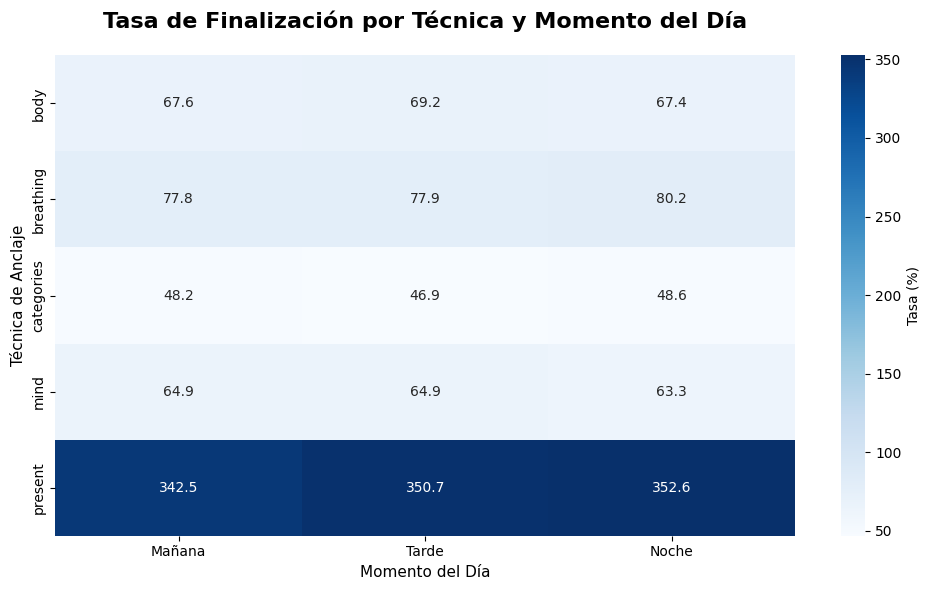

In [231]:
completion_by_time = data_cleaned.groupby(['techniqueID', 'time_of_day_range']).agg({
    'Grounding Started': 'sum',
    'Grounding Ended': 'sum'
}).reset_index()

completion_by_time['tasa_finalizacion'] = (
    completion_by_time['Grounding Ended'] / completion_by_time['Grounding Started'] * 100
)

pivot_data = completion_by_time.pivot(index='techniqueID', columns='time_of_day_range', values='tasa_finalizacion')
pivot_data = pivot_data[['Mañana', 'Tarde', 'Noche']]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Tasa (%)'}, ax=ax)

ax.set_title('Tasa de Finalización por Técnica y Momento del Día', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Momento del Día', fontsize=11)
ax.set_ylabel('Técnica de Anclaje', fontsize=11)

plt.tight_layout()
plt.show()


In [232]:
from plotly.subplots import make_subplots

usuarios_por_tecnica = data_cleaned.groupby('techniqueID').agg({
    'Grounding Started': 'sum',
    'Grounding Ended': 'sum'
}).reset_index()

techniques = usuarios_por_tecnica['techniqueID'].unique()
n_techs = len(techniques)

fig = make_subplots(
    rows=1, cols=n_techs,
    specs=[[{'type': 'domain'}] * n_techs],
    subplot_titles=[f'<b>{t}</b>' for t in techniques]
)

for i, tech in enumerate(techniques, start=1):
    tech_data = usuarios_por_tecnica[usuarios_por_tecnica['techniqueID'] == tech]
    ended = tech_data['Grounding Ended'].values[0]
    not_ended = tech_data['Grounding Started'].values[0] - ended

    fig.add_trace(go.Pie(
        labels=['Finalizados', 'No Finalizados'],
        values=[ended, not_ended],
        hole=0.4,
        marker_colors=['#4A90E2', '#E8E8E8'],
        textinfo='percent',
        showlegend=(i == 1)
    ), row=1, col=i)

apply_dashboard_theme(
    fig,
    'Proporción de Finalización por Técnica',
    'Cada gráfico circular muestra el porcentaje de ejercicios completados para cada técnica de anclaje.',
    height=500
)
fig.show()


In [233]:
#? Sankey diagram: Flujo de Técnicas a Estado de Finalización

import plotly.graph_objects as go

#? Calcular usuarios que iniciaron y finalizaron por técnica
usuarios_por_tecnica = data_cleaned.groupby('techniqueID').agg({
    'Grounding Started': 'sum',
    'Grounding Ended': 'sum'
}).reset_index()

usuarios_por_tecnica['No Finalizados'] = (
    usuarios_por_tecnica['Grounding Started'] - usuarios_por_tecnica['Grounding Ended']
)

#? Preparar nodos: técnicas + estados (Finalizados, No Finalizados)
techniques = usuarios_por_tecnica['techniqueID'].tolist()
estados = ['Finalizados', 'No Finalizados']
all_nodes = techniques + estados

#? Crear mapeo de índices
node_indices = {node: idx for idx, node in enumerate(all_nodes)}

#? Preparar links (source, target, value)
sources = []
targets = []
values = []
colors = []

for _, row in usuarios_por_tecnica.iterrows():
    tech = row['techniqueID']
    tech_idx = node_indices[tech]

    # Flujo a Finalizados
    if row['Grounding Ended'] > 0:
        sources.append(tech_idx)
        targets.append(node_indices['Finalizados'])
        values.append(row['Grounding Ended'])
        colors.append('rgba(74, 144, 226, 0.4)')  # Azul transparente

    # Flujo a No Finalizados
    if row['No Finalizados'] > 0:
        sources.append(tech_idx)
        targets.append(node_indices['No Finalizados'])
        values.append(row['No Finalizados'])
        colors.append('rgba(232, 232, 232, 0.7)')  # Gris transparente

#? Colores de nodos
node_colors = [TECHNIQUE_COLORS.get(tech, '#CCCCCC') for tech in techniques] + ['#4A90E2', '#AEAEAE']

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color='white', width=0.5),
        label=all_nodes,
        color=node_colors,
        customdata=[f'{node}' for node in all_nodes],
        hovertemplate='%{customdata}<br>Total: %{value:,.0f}<extra></extra>'
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=colors,
        hovertemplate='%{source.label} → %{target.label}<br>Eventos: %{value:,.0f}<extra></extra>'
    )
)])

apply_dashboard_theme(
    fig,
    'Flujo de Finalización por Técnica de Anclaje',
    'El diagrama Sankey muestra cómo los ejercicios iniciados en cada técnica fluyen hacia completados o no completados,\n'
    'revelando visualmente las tasas de adherencia y abandono.',
    height=700
)

fig.update_layout(
    font=dict(size=11),
    margin=dict(l=20, r=20, t=120, b=40)
)

fig.show()


### Porcentaje de Tecnicas usadas en conjunto o cercanas entre si

DIAGNÓSTICO DE DATOS
Total de eventos: 540023
Rango temporal: 2021-12-17 04:37:00 a 2022-03-16 16:46:00

Estadísticas de time_diff:
count                    540022
mean     0 days 00:00:14.320416
std      0 days 00:43:26.243986
min             0 days 00:00:00
25%             0 days 00:00:00
50%             0 days 00:00:00
75%             0 days 00:00:00
max            21 days 19:15:00
Name: time_diff, dtype: object

Eventos con gap > 60 min: 4
Eventos con gap <= 60 min: 540018

ANÁLISIS DE CO-OCURRENCIA CON ENFOQUE DIFF (VENTANAS DE 60 MINUTOS)
Total de sesiones detectadas: 5
Sesiones con múltiples técnicas: 2
Porcentaje: 40.00%

ANÁLISIS DE CO-OCURRENCIA CON ENFOQUE DIFF (VENTANAS DE 30 MINUTOS)
Total de ventanas detectadas: 10
Ventanas con múltiples técnicas: 7
Porcentaje: 70.00%


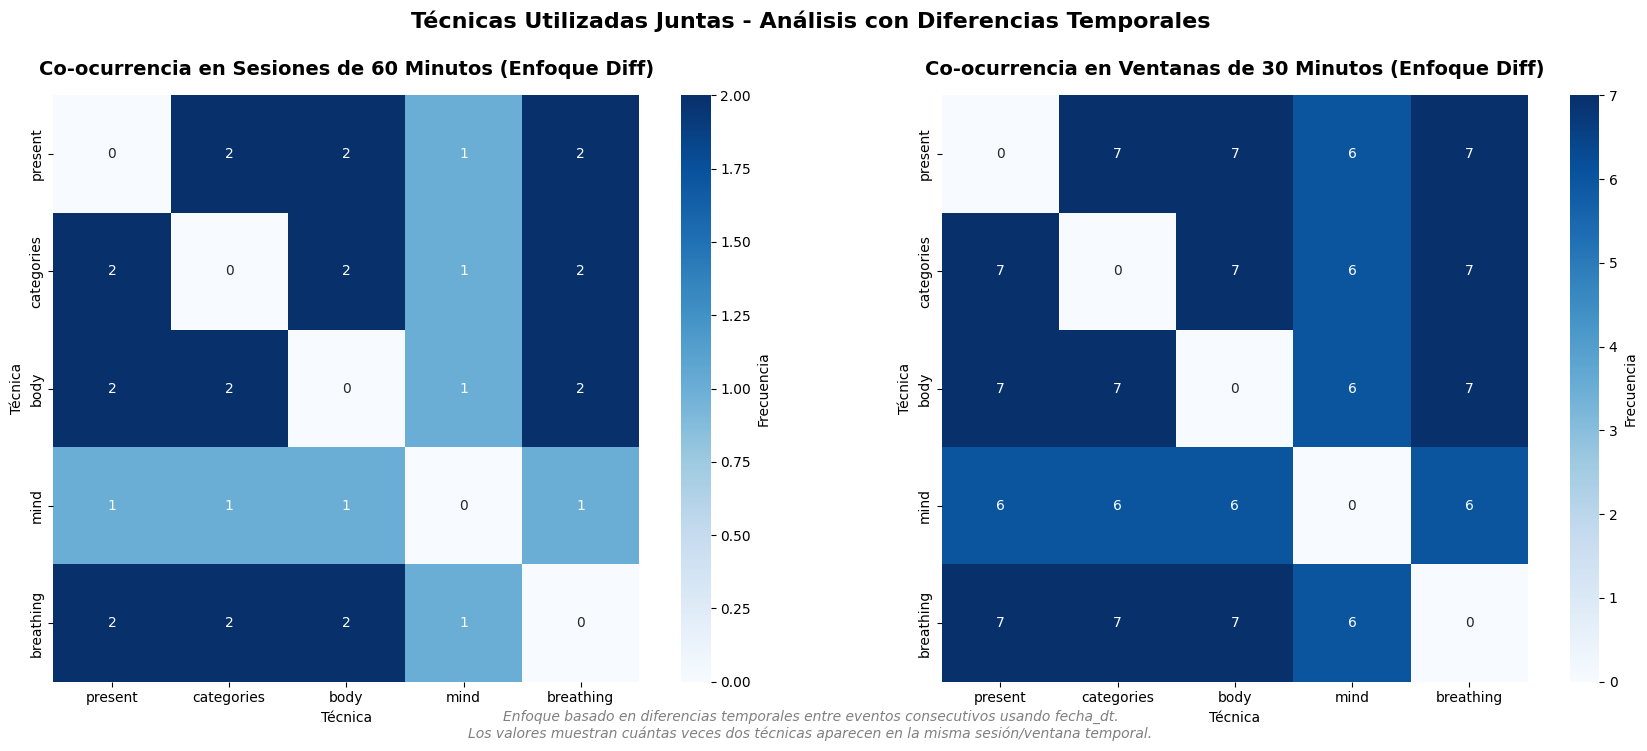


TOP 10 COMBINACIONES EN SESIONES DE 60 MINUTOS (ENFOQUE DIFF)
    Técnica 1   Técnica 2  Frecuencia
0     present  categories           2
1     present        body           2
3     present   breathing           2
4  categories        body           2
6  categories   breathing           2
8        body   breathing           2
2     present        mind           1
5  categories        mind           1
7        body        mind           1
9        mind   breathing           1

TOP 10 COMBINACIONES EN VENTANAS DE 30 MINUTOS (ENFOQUE DIFF)
    Técnica 1   Técnica 2  Frecuencia
0     present  categories           7
1     present        body           7
3     present   breathing           7
4  categories        body           7
6  categories   breathing           7
8        body   breathing           7
2     present        mind           6
5  categories        mind           6
7        body        mind           6
9        mind   breathing           6


In [241]:
#? Enfoque de ventanas temporales usando diferencias de tiempo (diff) para identificar co-ocurrencia
#? VERSIÓN CORREGIDA - Usando fecha_dt que contiene fecha y hora completa

from datetime import timedelta
from itertools import combinations



#? 2. Calcular diferencia de tiempo entre eventos consecutivos
#? Esto nos permite identificar "gaps" o brechas temporales entre eventos sucesivos
data_sorted['time_diff'] = data_sorted['date_dt'].diff()

#? 3. Definir umbrales para sesiones y momentos cercanos
gap_threshold_session = timedelta(minutes=60)  # Sesión: eventos separados por <= 60 minutos
gap_threshold_close = timedelta(minutes=30)    # Momentos cercanos: eventos separados por <= 30 minutos

#? 4. Identificar inicio de nuevas sesiones (ventanas de 60 minutos)
#? Si la diferencia de tiempo es mayor a 60 minutos O es el primer evento (NaN), inicia nueva sesión
data_sorted['new_session_60min'] = (data_sorted['time_diff'] > gap_threshold_session) | (data_sorted['time_diff'].isna())

#? 5. Asignar ID único a cada sesión mediante suma acumulativa de los marcadores de nueva sesión
data_sorted['session_id_60min'] = data_sorted['new_session_60min'].cumsum()

#? 6. Identificar inicio de nuevas ventanas de momentos cercanos (30 minutos)
data_sorted['new_session_30min'] = (data_sorted['time_diff'] > gap_threshold_close) | (data_sorted['time_diff'].isna())

#? 7. Asignar ID único a cada ventana de 30 minutos
data_sorted['session_id_30min'] = data_sorted['new_session_30min'].cumsum()

#? 8. Diagnóstico: Verificar que los datos son correctos
print("=" * 70)
print("DIAGNÓSTICO DE DATOS")
print("=" * 70)
print(f"Total de eventos: {len(data_sorted)}")
print(f"Rango temporal: {data_sorted['date_dt'].min()} a {data_sorted['date_dt'].max()}")
print(f"\nEstadísticas de time_diff:")
print(data_sorted['time_diff'].describe())
print(f"\nEventos con gap > 60 min: {(data_sorted['time_diff'] > gap_threshold_session).sum()}")
print(f"Eventos con gap <= 60 min: {((data_sorted['time_diff'] <= gap_threshold_session) & (data_sorted['time_diff'].notna())).sum()}")

#? 9. Agrupar técnicas por sesión de 60 minutos
session_cooccurrence_diff = (
    data_sorted.groupby('session_id_60min')['techniqueID']
    .apply(list)
    .reset_index()
)

#? 10. Calcular estadísticas de sesiones de 60 minutos
session_cooccurrence_diff['num_events'] = session_cooccurrence_diff['techniqueID'].apply(len)
session_cooccurrence_diff['unique_techniques'] = session_cooccurrence_diff['techniqueID'].apply(lambda x: len(set(x)))
session_cooccurrence_diff['technique_list'] = session_cooccurrence_diff['techniqueID'].apply(lambda x: list(set(x)))
session_cooccurrence_diff_multi = session_cooccurrence_diff[session_cooccurrence_diff['unique_techniques'] > 1].copy()

print("\n" + "=" * 70)
print("ANÁLISIS DE CO-OCURRENCIA CON ENFOQUE DIFF (VENTANAS DE 60 MINUTOS)")
print("=" * 70)
print(f"Total de sesiones detectadas: {len(session_cooccurrence_diff)}")
print(f"Sesiones con múltiples técnicas: {len(session_cooccurrence_diff_multi)}")
print(f"Porcentaje: {len(session_cooccurrence_diff_multi)/len(session_cooccurrence_diff)*100:.2f}%")

#? 11. Agrupar técnicas por ventana de 30 minutos
close_moment_cooccurrence_diff = (
    data_sorted.groupby('session_id_30min')['techniqueID']
    .apply(list)
    .reset_index()
)

#? 12. Calcular estadísticas de ventanas de 30 minutos
close_moment_cooccurrence_diff['num_events'] = close_moment_cooccurrence_diff['techniqueID'].apply(len)
close_moment_cooccurrence_diff['unique_techniques'] = close_moment_cooccurrence_diff['techniqueID'].apply(lambda x: len(set(x)))
close_moment_cooccurrence_diff['technique_list'] = close_moment_cooccurrence_diff['techniqueID'].apply(lambda x: list(set(x)))
close_moment_cooccurrence_diff_multi = close_moment_cooccurrence_diff[close_moment_cooccurrence_diff['unique_techniques'] > 1].copy()

print("\n" + "=" * 70)
print("ANÁLISIS DE CO-OCURRENCIA CON ENFOQUE DIFF (VENTANAS DE 30 MINUTOS)")
print("=" * 70)
print(f"Total de ventanas detectadas: {len(close_moment_cooccurrence_diff)}")
print(f"Ventanas con múltiples técnicas: {len(close_moment_cooccurrence_diff_multi)}")
print(f"Porcentaje: {len(close_moment_cooccurrence_diff_multi)/len(close_moment_cooccurrence_diff)*100:.2f}%")

#? 13. Crear matriz de co-ocurrencia para sesiones de 60 minutos
techniques = data_cleaned['techniqueID'].unique()
co_occurrence_60min_diff = pd.DataFrame(0, index=techniques, columns=techniques)

for tech_list in session_cooccurrence_diff_multi['techniqueID']:
    unique_techs = list(set(tech_list))  # Eliminar duplicados dentro de la misma sesión
    if len(unique_techs) > 1:
        #? Para cada par de técnicas únicas en la sesión, incrementar contador
        for tech1, tech2 in combinations(unique_techs, 2):
            co_occurrence_60min_diff.loc[tech1, tech2] += 1
            co_occurrence_60min_diff.loc[tech2, tech1] += 1

#? 14. Crear matriz de co-ocurrencia para ventanas de 30 minutos
co_occurrence_30min_diff = pd.DataFrame(0, index=techniques, columns=techniques)

for tech_list in close_moment_cooccurrence_diff_multi['techniqueID']:
    unique_techs = list(set(tech_list))
    if len(unique_techs) > 1:
        for tech1, tech2 in combinations(unique_techs, 2):
            co_occurrence_30min_diff.loc[tech1, tech2] += 1
            co_occurrence_30min_diff.loc[tech2, tech1] += 1

#? 15. Visualización: Heatmaps comparativos de co-ocurrencia con enfoque diff
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#? 15.1 Heatmap para sesiones de 60 minutos
sns.heatmap(
    co_occurrence_60min_diff,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar_kws={'label': 'Frecuencia'},
    ax=axes[0],
    square=True
)
axes[0].set_title('Co-ocurrencia en Sesiones de 60 Minutos (Enfoque Diff)',
                  fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Técnica', fontsize=10)
axes[0].set_ylabel('Técnica', fontsize=10)

#? 15.2 Heatmap para ventanas de 30 minutos
sns.heatmap(
    co_occurrence_30min_diff,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar_kws={'label': 'Frecuencia'},
    ax=axes[1],
    square=True
)
axes[1].set_title('Co-ocurrencia en Ventanas de 30 Minutos (Enfoque Diff)',
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Técnica', fontsize=10)
axes[1].set_ylabel('Técnica', fontsize=10)

fig.suptitle(
    'Técnicas Utilizadas Juntas - Análisis con Diferencias Temporales',
    fontsize=16, fontweight='bold', y=1.02
)
fig.text(
    0.5, -0.02,
    'Enfoque basado en diferencias temporales entre eventos consecutivos usando fecha_dt.\n'
    'Los valores muestran cuántas veces dos técnicas aparecen en la misma sesión/ventana temporal.',
    ha='center', fontsize=10, fontstyle='italic', color='gray'
)

plt.tight_layout()
plt.show()

#? 16. Análisis de las combinaciones más frecuentes (60 minutos)
print("\n" + "=" * 70)
print("TOP 10 COMBINACIONES EN SESIONES DE 60 MINUTOS (ENFOQUE DIFF)")
print("=" * 70)
pairs_60min_diff = []
for i, tech1 in enumerate(techniques):
    for j, tech2 in enumerate(techniques):
        if i < j and co_occurrence_60min_diff.loc[tech1, tech2] > 0:
            pairs_60min_diff.append({
                'Técnica 1': tech1,
                'Técnica 2': tech2,
                'Frecuencia': co_occurrence_60min_diff.loc[tech1, tech2]
            })

pairs_60min_diff_df = pd.DataFrame(pairs_60min_diff).sort_values('Frecuencia', ascending=False)
print(pairs_60min_diff_df.head(10))

#? 17. Análisis de las combinaciones más frecuentes (30 minutos)
print("\n" + "=" * 70)
print("TOP 10 COMBINACIONES EN VENTANAS DE 30 MINUTOS (ENFOQUE DIFF)")
print("=" * 70)
pairs_30min_diff = []
for i, tech1 in enumerate(techniques):
    for j, tech2 in enumerate(techniques):
        if i < j and co_occurrence_30min_diff.loc[tech1, tech2] > 0:
            pairs_30min_diff.append({
                'Técnica 1': tech1,
                'Técnica 2': tech2,
                'Frecuencia': co_occurrence_30min_diff.loc[tech1, tech2]
            })

pairs_30min_diff_df = pd.DataFrame(pairs_30min_diff).sort_values('Frecuencia', ascending=False)
print(pairs_30min_diff_df.head(10))


DISTRIBUCIÓN DE SESIONES DE 60 MINUTOS POR NÚMERO DE TÉCNICAS (DIFF)
1 técnica(s): 3 sesiones (60.00%)
4 técnica(s): 1 sesiones (20.00%)
5 técnica(s): 1 sesiones (20.00%)

DISTRIBUCIÓN DE VENTANAS DE 30 MINUTOS POR NÚMERO DE TÉCNICAS (DIFF)
1 técnica(s): 3 ventanas (30.00%)
4 técnica(s): 1 ventanas (10.00%)
5 técnica(s): 6 ventanas (60.00%)

RESUMEN - SESIONES/VENTANAS CON MÚLTIPLES TÉCNICAS (DIFF)
Sesiones de 60 min con 2+ técnicas: 2 (40.00%)
Ventanas de 30 min con 2+ técnicas: 7 (70.00%)


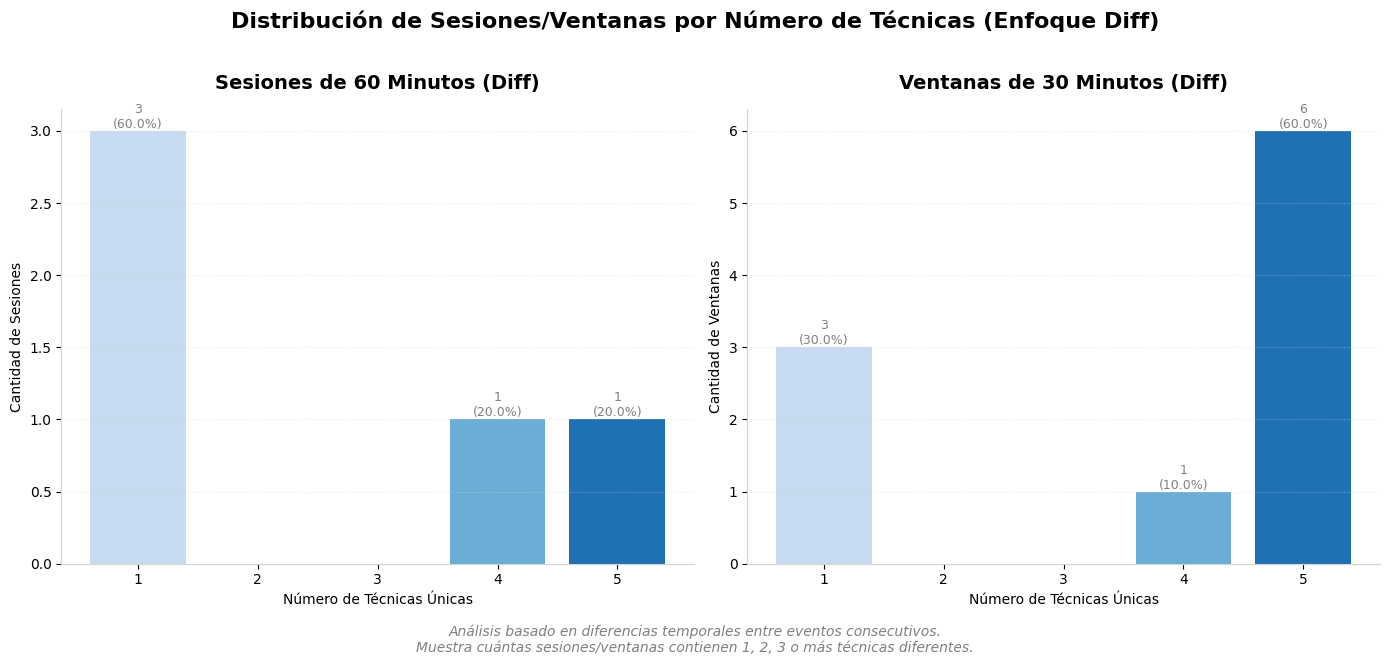


TOP 10 COMBINACIONES ESPECÍFICAS - SESIONES DE 60 MINUTOS (DIFF)
                                      Combinación  Frecuencia
0         body + breathing + categories + present           1
1  body + breathing + categories + mind + present           1

TOP 10 COMBINACIONES ESPECÍFICAS - VENTANAS DE 30 MINUTOS (DIFF)
                                      Combinación  Frecuencia
1  body + breathing + categories + mind + present           6
0         body + breathing + categories + present           1

ESTADÍSTICAS DE TAMAÑO DE COMBINACIONES
Sesiones de 60 min:
  - Combinaciones de 2 técnicas: 0
  - Combinaciones de 3 técnicas: 0
  - Combinaciones de 4+ técnicas: 2

Ventanas de 30 min:
  - Combinaciones de 2 técnicas: 0
  - Combinaciones de 3 técnicas: 0
  - Combinaciones de 4+ técnicas: 2


In [238]:
#? Análisis de sesiones por cantidad de técnicas utilizadas (Enfoque Diff)

from itertools import combinations

#? 1. Calcular técnicas únicas por sesión de 60 minutos
session_cooccurrence_diff['unique_techniques'] = session_cooccurrence_diff['techniqueID'].apply(lambda x: len(set(x)))
session_cooccurrence_diff['technique_list'] = session_cooccurrence_diff['techniqueID'].apply(lambda x: list(set(x)))

#? 2. Contar sesiones por número de técnicas únicas (60 minutos)
session_technique_counts_diff = session_cooccurrence_diff['unique_techniques'].value_counts().sort_index()

print("=" * 70)
print("DISTRIBUCIÓN DE SESIONES DE 60 MINUTOS POR NÚMERO DE TÉCNICAS (DIFF)")
print("=" * 70)
for num_techs, count in session_technique_counts_diff.items():
    pct = count / len(session_cooccurrence_diff) * 100
    print(f"{num_techs} técnica(s): {count} sesiones ({pct:.2f}%)")

#? 3. Calcular técnicas únicas por ventana de 30 minutos
close_moment_cooccurrence_diff['unique_techniques'] = close_moment_cooccurrence_diff['techniqueID'].apply(lambda x: len(set(x)))
close_moment_cooccurrence_diff['technique_list'] = close_moment_cooccurrence_diff['techniqueID'].apply(lambda x: list(set(x)))

#? 4. Contar ventanas por número de técnicas únicas (30 minutos)
close_moment_technique_counts_diff = close_moment_cooccurrence_diff['unique_techniques'].value_counts().sort_index()

print("\n" + "=" * 70)
print("DISTRIBUCIÓN DE VENTANAS DE 30 MINUTOS POR NÚMERO DE TÉCNICAS (DIFF)")
print("=" * 70)
for num_techs, count in close_moment_technique_counts_diff.items():
    pct = count / len(close_moment_cooccurrence_diff) * 100
    print(f"{num_techs} técnica(s): {count} ventanas ({pct:.2f}%)")

#? 5. Filtrar sesiones/ventanas con 2 o más técnicas
session_multi_tech_diff = session_cooccurrence_diff[session_cooccurrence_diff['unique_techniques'] >= 2]
close_moment_multi_tech_diff = close_moment_cooccurrence_diff[close_moment_cooccurrence_diff['unique_techniques'] >= 2]

print("\n" + "=" * 70)
print("RESUMEN - SESIONES/VENTANAS CON MÚLTIPLES TÉCNICAS (DIFF)")
print("=" * 70)
print(f"Sesiones de 60 min con 2+ técnicas: {len(session_multi_tech_diff)} ({len(session_multi_tech_diff)/len(session_cooccurrence_diff)*100:.2f}%)")
print(f"Ventanas de 30 min con 2+ técnicas: {len(close_moment_multi_tech_diff)} ({len(close_moment_multi_tech_diff)/len(close_moment_cooccurrence_diff)*100:.2f}%)")

#? 6. Visualización: Gráfico de barras comparativo (Enfoque Diff)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#? 6.1 Gráfico para sesiones de 60 minutos
colors_60min = generate_blue_palette(len(session_technique_counts_diff))
axes[0].bar(session_technique_counts_diff.index, session_technique_counts_diff.values, color=colors_60min)
axes[0].set_title('Sesiones de 60 Minutos (Diff)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Número de Técnicas Únicas', fontsize=10)
axes[0].set_ylabel('Cantidad de Sesiones', fontsize=10)
axes[0].grid(True, axis='y', color='lightgray', linestyle='--', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_color('lightgray')
axes[0].spines['bottom'].set_color('lightgray')

#? 6.2 Añadir etiquetas con conteo y porcentaje (60 minutos)
for i, (num, count) in enumerate(session_technique_counts_diff.items()):
    axes[0].text(num, count, f'{count}\n({count/len(session_cooccurrence_diff)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9, color='gray')

#? 6.3 Gráfico para ventanas de 30 minutos
colors_30min = generate_blue_palette(len(close_moment_technique_counts_diff))
axes[1].bar(close_moment_technique_counts_diff.index, close_moment_technique_counts_diff.values, color=colors_30min)
axes[1].set_title('Ventanas de 30 Minutos (Diff)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Número de Técnicas Únicas', fontsize=10)
axes[1].set_ylabel('Cantidad de Ventanas', fontsize=10)
axes[1].grid(True, axis='y', color='lightgray', linestyle='--', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_color('lightgray')
axes[1].spines['bottom'].set_color('lightgray')

#? 6.4 Añadir etiquetas con conteo y porcentaje (30 minutos)
for i, (num, count) in enumerate(close_moment_technique_counts_diff.items()):
    axes[1].text(num, count, f'{count}\n({count/len(close_moment_cooccurrence_diff)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9, color='gray')

#? 6.5 Título y subtítulo del gráfico completo
fig.suptitle(
    'Distribución de Sesiones/Ventanas por Número de Técnicas (Enfoque Diff)',
    fontsize=16, fontweight='bold', y=1.02
)
fig.text(
    0.5, -0.05,
    'Análisis basado en diferencias temporales entre eventos consecutivos.\n'
    'Muestra cuántas sesiones/ventanas contienen 1, 2, 3 o más técnicas diferentes.',
    ha='center', fontsize=10, fontstyle='italic', color='gray'
)

plt.tight_layout()
plt.show()

#? 7. Análisis detallado: Combinaciones específicas más frecuentes (60 minutos)
print("\n" + "=" * 70)
print("TOP 10 COMBINACIONES ESPECÍFICAS - SESIONES DE 60 MINUTOS (DIFF)")
print("=" * 70)
combination_counts_60min = {}

for tech_list in session_multi_tech_diff['technique_list']:
    if len(tech_list) >= 2:
        #? Crear tupla ordenada para evitar duplicados (A,B) vs (B,A)
        combo = tuple(sorted(tech_list))
        combination_counts_60min[combo] = combination_counts_60min.get(combo, 0) + 1

#? Convertir a DataFrame y ordenar por frecuencia descendente
combo_60min_df = pd.DataFrame([
    {'Combinación': ' + '.join(combo), 'Frecuencia': count}
    for combo, count in combination_counts_60min.items()
]).sort_values('Frecuencia', ascending=False)

print(combo_60min_df.head(10))

#? 8. Análisis detallado: Combinaciones específicas más frecuentes (30 minutos)
print("\n" + "=" * 70)
print("TOP 10 COMBINACIONES ESPECÍFICAS - VENTANAS DE 30 MINUTOS (DIFF)")
print("=" * 70)
combination_counts_30min = {}

for tech_list in close_moment_multi_tech_diff['technique_list']:
    if len(tech_list) >= 2:
        combo = tuple(sorted(tech_list))
        combination_counts_30min[combo] = combination_counts_30min.get(combo, 0) + 1

combo_30min_df = pd.DataFrame([
    {'Combinación': ' + '.join(combo), 'Frecuencia': count}
    for combo, count in combination_counts_30min.items()
]).sort_values('Frecuencia', ascending=False)

print(combo_30min_df.head(10))

#? 9. Estadísticas adicionales: Distribución de tamaño de combinaciones
print("\n" + "=" * 70)
print("ESTADÍSTICAS DE TAMAÑO DE COMBINACIONES")
print("=" * 70)

#? 9.1 Para sesiones de 60 minutos
combo_sizes_60min = [len(combo) for combo in combination_counts_60min.keys()]
if combo_sizes_60min:
    print(f"Sesiones de 60 min:")
    print(f"  - Combinaciones de 2 técnicas: {combo_sizes_60min.count(2)}")
    print(f"  - Combinaciones de 3 técnicas: {combo_sizes_60min.count(3)}")
    print(f"  - Combinaciones de 4+ técnicas: {sum(1 for x in combo_sizes_60min if x >= 4)}")

#? 9.2 Para ventanas de 30 minutos
combo_sizes_30min = [len(combo) for combo in combination_counts_30min.keys()]
if combo_sizes_30min:
    print(f"\nVentanas de 30 min:")
    print(f"  - Combinaciones de 2 técnicas: {combo_sizes_30min.count(2)}")
    print(f"  - Combinaciones de 3 técnicas: {combo_sizes_30min.count(3)}")
    print(f"  - Combinaciones de 4+ técnicas: {sum(1 for x in combo_sizes_30min if x >= 4)}")
